乳腺癌数据集
datasets/Human_breast_cancer/Human_breast_cancer_ViHBC/Human_breast_cancer_integrated.h5ad
使用修改后的十个四元组

📂 一、 最终生成的文件清单 (Outputs)
你的代码会在指定的输出目录（outputs/Human_breast_cancer_ViHBC/）中生成以下两大类文件：
1. SpaCET 相关的基础指标文件夹 (zhibiao/SpaCET/)
🖼️ GMM_Malignant_Threshold_Plot.png：双峰高斯分布拟合图（完美解释你为何不切 0.5 而是自适应寻找阈值，可放论文 Supplementary）。
📊 GMM_Optimal_Threshold_Result.csv：记录了 GMM 算出来的具体最优阈值数值（如 0.4532）。
📊 GMM_Tumor_NonTumor_Pred_Labels.csv：仅包含 Spot ID、连续恶性分数和二分类预测标签的轻量级结果表。
2. 最终层级生态位文件夹 (Final_Hierarchical_Niches/)
🖼️ Hierarchical_Niche_Map.png：（如果取消注释）左图为 Level 1 宏观肿瘤/健康区域，右图为 Level 2 纯化后的代谢微生态位空间图（极具视觉冲击力的核心主图）。
📊 Level2_Niche_Counts.csv：（如果取消注释）每种代谢生态位（如乳酸轴、谷氨酰胺轴、休眠区等）所占的 Spot 数量统计，可直接用于画饼图或柱状图。
📊 ARI_Tumor_Segmentation_Result.csv：你的跨模态联合区域与病理医生金标准的 ARI 评估结果得分（证明模型准确性的黄金表格）。
🧬 Human_breast_cancer_ViHBC_TCMN_Final.h5ad：【最核心资产】 包含了原始基因矩阵、空间坐标、以及下面列出的所有极其丰富的 metadata 标签！

终极 h5ad 文件的核心信息列 (adata.obs)
当你未来在其他脚本中加载 adata = ad.read_h5ad("..._TCMN_Final.h5ad") 时，你的 adata.obs 就成了一座数据宝库。我将其分为 5 大逻辑模块：
🥇 模块 1：终极输出标签（你后续分析最常用的列）
列名 (adata.obs Columns)	含义与示例	用途
Level2_Micro_Niche	最终的纯化代谢微型生态位。示例：TMCN_Lactate_Axis（单轴）, TMCN_Glutamine_Lactate_Multi_Axis（多轴）, TMCN_Quiescent（死寂区）, Healthy_Region。	全篇论文的核心分组依据。后续画差异表达、小提琴图、细胞通讯弦图，全部基于这个列进行 groupby。
Level1_Macro_Region	宏观肿瘤微环境边界。示例：Tumor_Region，Healthy_Region。	用于比较全肿瘤内部与外部健康基质的宏观差异。
🥈 模块 2：你最新要求的“多轴活跃比例”（量化混合生态位特征）
对于 10 条轴的每一条，都有以下列（以 Lactate 为例）：
| 列名 | 含义与示例 | 用途 |
| :--- | :--- | :--- |
| Lactate_Cluster_Active_Frac | 本聚类内乳酸轴突破活跃阈值的 Spot 比例（0.0 ~ 1.0）。示例：0.85 | 极高价值！证明 Multi_Axis 生态位不是强行命名的，而是例如 乳酸=0.85 且 谷氨酰胺=0.62 真实双高并存的。可用此列画散点相关性图。 |
🥉 模块 3：连续生化特征与耦合打分（空间连续信号）
对于 10 条轴的每一条，都有以下列（以 Lactate 为例）：
| 列名 | 含义与示例 | 用途 |
| :--- | :--- | :--- |
| Lactate_Sender_Score | 自身发射能力 (PROGENy通路 × 代谢酶)。连续值 (01)。 | 用来画单一生化功能的空间热力渐变图。 |
| Lactate_Receiver_Score | 自身接收能力 (受体表达)。连续值 (01)。 | 同上。 |
| Coupling_Lactate | 真实空间通讯耦合分数 (Log1p(Sender × 物理邻居Receiver))。 | 最硬核的特征。反映该 Spot 正在经历多强的空间物质流动。是后续推断因果通讯权重（阶段五）的基础！ |
🏅 模块 4：跨模态基准标签（模型决策依据）
列名	含义与示例	用途
Malignant	SpaCET 原始输出的连续恶性比例（0~1）。	展示 SpaCET 原始视野。
Unsupervised_Pred_0.45	GMM自动阈值二分类（Predicted_Tumor / Non_Tumor）。	Level 1 宏观划界的基础之一。
annot_type	原始人工病理标注 (Tumor, Surrounding tumor...)	仅用于计算 ARI 和金标准对比对照，不参与我们无监督模型的生成逻辑，保证算法清白。
Ground_Truth_Binary	统一为 Tumor_Region / Non_Tumor_Region。	方便直接与 Level1_Macro_Region 做混淆矩阵分析。
🎖️ 模块 5：底层无监督拓扑结构（追溯使用）
列名	含义与示例	用途
latent_leiden_0.4	NicheCompass 跑出来的原始图神经聚类（如 0, 1, 2...）。	证明我们并没有改变算法底层的物理骨架。
Final_Niche_Type	平滑去噪后的初始代谢标签（未与 SpaCET 结合的纯代谢版本）。	可以用来对比“结合 SpaCET 前后”到底纠正了多少假阳性。
💡 总结：后续你可以怎么用这个 h5ad？
这个 h5ad 是一张完美标注的肿瘤生态位寻宝图。
如果你想验证多轴（Multi-axis）的生物学意义：
直接取子集：adata_multi = adata[adata.obs['Level2_Micro_Niche'] == 'TMCN_Glutamine_Lactate_Multi_Axis']
然后查看：adata_multi.obs[['Glutamine_Cluster_Active_Frac', 'Lactate_Cluster_Active_Frac']]，你会发现这两列的数值都非常高（>0.3），完美印证了微环境在这片区域同时进行着两套代谢途径。
如果你想进行下一步（阶段四：通讯推断）：
你可以直接调用 Coupling_{Axis} 列作为权重源，调用 Level2_Micro_Niche 作为节点分组（Node Type），毫无障碍地生成空间有向弦图（Chord diagram）或向量场图（Vector fields）。

使用SpaCET得出spot反卷积结果和肿瘤非肿瘤标签

In [14]:
# =========================================================
# Cell 1: 数据加载、基因名校验与 SpaCET 结果合并
# 功能：直接将CSV结果注入原始h5ad，不生成新文件，覆盖原文件
# =========================================================
import anndata as ad
import pandas as pd
import os

print("="*60)
# 1. 仅设置原始文件路径（删除输出路径，无新文件）
path_h5ad_original = "/home/zhangjunyi/xiangmu/nichecompass-main/datasets/12_colorectal_cancer_CRC/12_colorectal_cancer_CRC_h5ad/SN84_A120838_Rep1.h5ad"
path_spacet_csv = "/home/zhangjunyi/xiangmu/nichecompass-main/datasets/SpaCET_R_Result/12_colorectal_cancer_CRC/SN84_A120838_Rep1/SpaCET_CellFractions_Result.csv"

# 2. 读取原始 h5ad
print("正在读取原始 h5ad 文件...")
adata = ad.read_h5ad(path_h5ad_original)
print("文件读取成功！")
print("="*60)

# 3. 基因名格式校验（保留原逻辑）
print("【前 20 个基因名】：")
gene_names = adata.var.index.tolist()
print(gene_names[:20])
print("="*60)

if gene_names[0].startswith("ENSG"):
    print("❌ 检测结果：Ensembl ID 格式（需要转换为 Gene Symbol！）")
else:
    print("✅ 检测结果：标准 Gene Symbol 格式")
    print("🎉 完美！可以直接运行 SpaCET 代码，无需任何修改！")

# 4. 读取 SpaCET 结果 + Spot ID 对齐校验（保留原逻辑）
spacet_df = pd.read_csv(path_spacet_csv, index_col=0)
print(f"✅ 原始 h5ad 包含 {adata.n_obs} 个 Spots | SpaCET 结果包含 {spacet_df.shape[0]} 个 Spots")

common_spots = adata.obs_names.intersection(spacet_df.index)
if len(common_spots) == 0:
    raise ValueError("❌ 错误：原始 h5ad 和 SpaCET 结果没有匹配的 Spot ID！")
elif len(common_spots) < adata.n_obs:
    print(f"⚠️  警告：有 {adata.n_obs - len(common_spots)} 个 Spots 在 SpaCET 结果中未找到（已过滤）。")
    adata = adata[common_spots].copy()

# 5. 合并数据到 adata.obs（核心注入逻辑）
print("正在将CSV数据注入原始h5ad...")
spacet_df_aligned = spacet_df.reindex(adata.obs_names)

# 🔥 核心修复：自动删除重复列，实现覆盖效果
overlap_cols = spacet_df_aligned.columns.intersection(adata.obs.columns)
if len(overlap_cols) > 0:
    print(f"⚠️ 发现重复列，将自动覆盖：{overlap_cols.tolist()}")
    adata.obs = adata.obs.drop(columns=overlap_cols)  # 删除旧列

# 合并新数据（无冲突，安全执行）
adata.obs = adata.obs.join(spacet_df_aligned)

print("✅ 注入完成！adata.obs 中新增了以下列：")
print(spacet_df_aligned.columns.tolist())

# =========================================================
# 6. 物理清洗：剔除无病理注释及 exclude 的 Spot (新增逻辑)
# =========================================================
print("="*60)
print("正在执行最终数据清洗...")

# 确保列名正确
annot_col = 'pathology_annotation'
if annot_col in adata.obs.columns:
    # 1. 将注释转换为字符串并去除空格
    raw_annots = adata.obs[annot_col].astype(str).str.strip()
    
    # 2. 定义无效标签：包括 'exclude'、'nan'、'NaN'、'None' 和纯空格空值
    # 同时利用 adata.obs[annot_col].notna() 过滤掉真正的 Pandas NaN
    invalid_tags = ['exclude', 'nan', 'NaN', 'None', '', 'NA']
    
    valid_mask = (adata.obs[annot_col].notna()) & (~raw_annots.isin(invalid_tags))
    
    initial_count = adata.n_obs
    adata = adata[valid_mask].copy()
    removed_count = initial_count - adata.n_obs
    
    print(f"🧹 清理完毕：")
    print(f"   - 原始 Spot 数量: {initial_count}")
    print(f"   - 剔除无效/未标注 Spot 数量: {removed_count}")
    print(f"   - 最终保留有效 Spot 数量: {adata.n_obs}")
    
    if removed_count == 0:
        print("✅ 检查结果：该切片所有 Spot 均有有效病理标注。")
else:
    print(f"⚠️ 警告：未在 adata.obs 中找到 '{annot_col}' 列，跳过清洗步骤。")

# =========================================================
# 7. 直接覆盖保存原始h5ad
# =========================================================
print("="*60)
print(f"正在覆盖保存清洗后的原始文件：{path_h5ad_original}")
adata.write_h5ad(path_h5ad_original)
print("🎉 全部完成！SpaCET 结果已注入，且已物理剔除无标注区域。")

正在读取原始 h5ad 文件...
文件读取成功！
【前 20 个基因名】：
['MIR1302-2HG', 'FAM138A', 'OR4F5', 'AL627309.1', 'AL627309.3', 'AL627309.2', 'AL627309.5', 'AL627309.4', 'AP006222.2', 'AL732372.1', 'OR4F29', 'AC114498.1', 'OR4F16', 'AL669831.2', 'LINC01409', 'FAM87B', 'LINC01128', 'LINC00115', 'FAM41C', 'AL645608.6']
✅ 检测结果：标准 Gene Symbol 格式
🎉 完美！可以直接运行 SpaCET 代码，无需任何修改！
✅ 原始 h5ad 包含 240 个 Spots | SpaCET 结果包含 328 个 Spots
正在将CSV数据注入原始h5ad...
⚠️ 发现重复列，将自动覆盖：['Malignant', 'CAF', 'Endothelial', 'Plasma', 'B cell', 'T CD4', 'T CD8', 'NK', 'cDC', 'pDC', 'Macrophage', 'Mast', 'Neutrophil', 'Unidentifiable', 'B cell naive', 'B cell non-switched memory', 'B cell switched memory', 'B cell exhausted', 'T CD4 naive', 'Th1', 'Th2', 'Th17', 'Tfh', 'Treg', 'T CD8 naive', 'T CD8 central memory', 'T CD8 effector memory', 'T CD8 effector', 'T CD8 exhausted', 'cDC1 CLEC9A', 'cDC2 CD1C', 'cDC3 LAMP3', 'Macrophage M1', 'Macrophage M2', 'Macrophage other']
✅ 注入完成！adata.obs 中新增了以下列：
['Malignant', 'CAF', 'Endothelial', 'Plasma', 'B c

SpaCET
使用GMM计算阈值
高斯混合模型 (Gaussian Mixture Model, GMM)：假设数据由“低分（非肿瘤）”和“高分（肿瘤）”两个正态分布混合而成，寻找两个分布概率相交的点作为阈值。（最推荐，能处理方差不同的分布）

正在加载数据...
正在使用高斯混合模型 (GMM) 拟合数据分布...
✨ [无监督] 自动计算出的最优划分阈值为: 0.4628
✅ 图片已保存至: /home/zhangjunyi/xiangmu/nichecompass-main/outputs/colorectal_12_cancer_CRC/SN84_A120838_Rep1/SpaCET/GMM_Malignant_Threshold_Plot.png


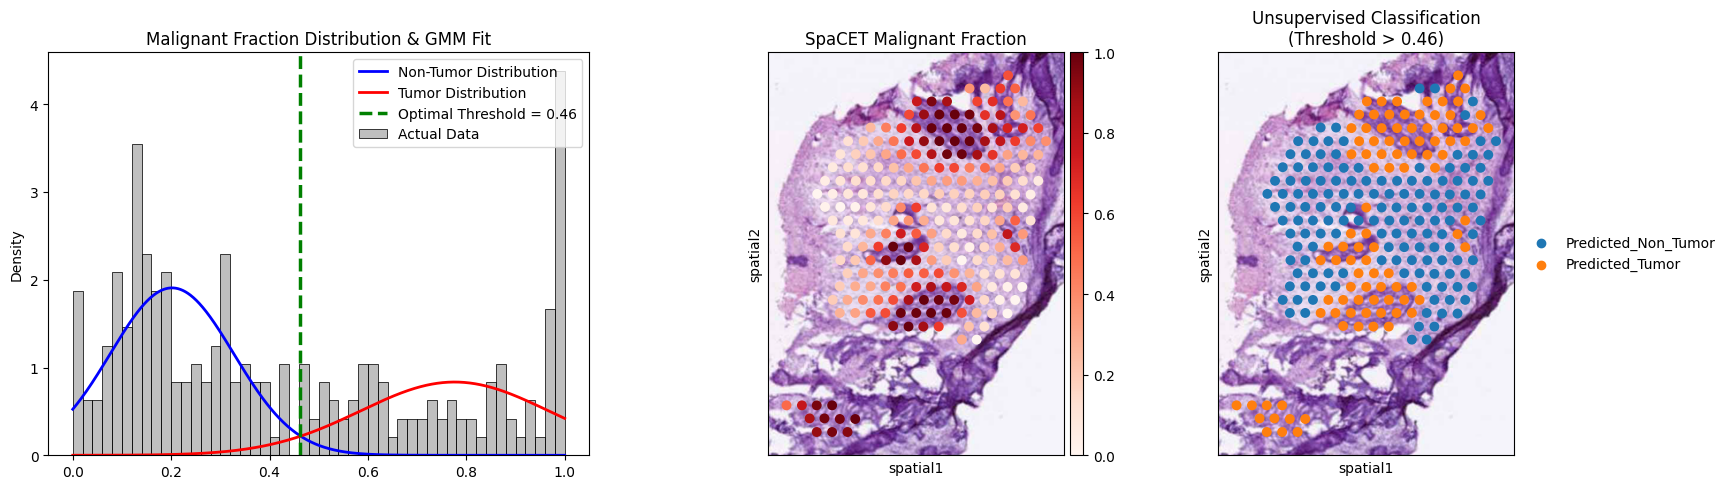

🎉 全部完成！所有文件已保存至指定文件夹


In [1]:
# =========================================================
# Cell 1-1: SpaCET 恶性分数 GMM 无监督自适应阈值计算
# =========================================================
import anndata as ad
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
import os

# 🔥 固定输出路径
SAVE_DIR = "/home/zhangjunyi/xiangmu/nichecompass-main/outputs/colorectal_12_cancer_CRC/SN84_A120838_Rep1/SpaCET"
os.makedirs(SAVE_DIR, exist_ok=True)

# 1. 读取数据
file_path = "/home/zhangjunyi/xiangmu/nichecompass-main/datasets/12_colorectal_cancer_CRC/12_colorectal_cancer_CRC_h5ad/SN84_A120838_Rep1.h5ad"
print("正在加载数据...")
adata = ad.read_h5ad(file_path)

# 2. 提取 SpaCET 的 Malignant 分数并使用 GMM 拟合
malignant_scores = adata.obs['Malignant'].dropna().values
X = malignant_scores.reshape(-1, 1)

print("正在使用高斯混合模型 (GMM) 拟合数据分布...")
gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=42)
gmm.fit(X)

means = gmm.means_.flatten()
class_non_tumor_idx, class_tumor_idx = np.argmin(means), np.argmax(means)

# 寻找边界交点
x_test = np.linspace(means[class_non_tumor_idx], means[class_tumor_idx], 1000).reshape(-1, 1)
preds = gmm.predict(x_test)
flip_index = np.where(preds[:-1] != preds[1:])[0]

optimal_threshold = x_test[flip_index[0]][0] if len(flip_index) > 0 else np.mean(means)
print(f"✨ [无监督] 自动计算出的最优划分阈值为: {optimal_threshold:.4f}")

# 3. 应用划分
col_name = f'Unsupervised_Pred_{optimal_threshold:.2f}'
adata.obs[col_name] = np.where(adata.obs['Malignant'] > optimal_threshold, 'Predicted_Tumor', 'Predicted_Non_Tumor')
adata.obs[col_name] = adata.obs[col_name].astype('category')

# 4. 可视化
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# 子图1: 分布
sns.histplot(malignant_scores, bins=50, stat='density', alpha=0.5, color='gray', ax=axs[0], label='Actual Data')
x_plot = np.linspace(0, 1, 1000).reshape(-1, 1)
pdf = np.exp(gmm.score_samples(x_plot))
resps = gmm.predict_proba(x_plot)
axs[0].plot(x_plot, pdf * resps[:, class_non_tumor_idx], color='blue', label='Non-Tumor Distribution', lw=2)
axs[0].plot(x_plot, pdf * resps[:, class_tumor_idx], color='red', label='Tumor Distribution', lw=2)
axs[0].axvline(optimal_threshold, color='green', linestyle='--', lw=2.5, label=f'Optimal Threshold = {optimal_threshold:.2f}')
axs[0].set_title('Malignant Fraction Distribution & GMM Fit')
axs[0].legend()

# 子图2 & 3: 空间图
sc.pl.spatial(adata, color='Malignant', title='SpaCET Malignant Fraction', size=1, cmap='Reds', ax=axs[1], show=False)
sc.pl.spatial(adata, color=col_name, title=f'Unsupervised Classification\n(Threshold > {optimal_threshold:.2f})', size=1, ax=axs[2], show=False)

plt.tight_layout()

# 🔥 保存输出
img_save_path = os.path.join(SAVE_DIR, "GMM_Malignant_Threshold_Plot.png")
plt.savefig(img_save_path, dpi=300, bbox_inches='tight')
print(f"✅ 图片已保存至: {img_save_path}")
plt.show()

label_df = adata.obs[[col_name, 'Malignant']].copy()
label_df.index.name = "Spot_ID"
label_df.to_csv(os.path.join(SAVE_DIR, "GMM_Tumor_NonTumor_Pred_Labels.csv"), encoding='utf-8-sig')

pd.DataFrame({"Metric": ["Optimal_GMM_Threshold"], "Value": [round(optimal_threshold, 4)]}).to_csv(
    os.path.join(SAVE_DIR, "GMM_Optimal_Threshold_Result.csv"), index=False, encoding='utf-8-sig')
print("🎉 全部完成！所有文件已保存至指定文件夹")

SpaCET
利用当前阈值计算ARI
由于有些spot没有病理注释，所以要先清理，但是可以后续进行一个额外分析

正在加载原始数据...
🧹 清理前，切片总 Spot 数量: 240
✨ 清理后，切片总 Spot 数量: 240
🗑️ 共永久删除了 0 个无注释或 exclude 噪点。

--- 当前保留下来的纯净病理注释分布 ---
stroma_fibroblastic_IC high    103
tumor                           43
tumor&stroma_IC med to high     37
stroma_fibroblastic_IC low      33
stroma_fibroblastic_IC med      20
tumor&stroma_IC low              4
Name: pathology_annotation, dtype: int64

正在将纯净版数据覆盖保存至原路径...
✅ 清理并保存成功！文件路径: /home/zhangjunyi/xiangmu/nichecompass-main/datasets/12_colorectal_cancer_CRC/12_colorectal_cancer_CRC_h5ad/SN84_A120838_Rep1.h5ad
后续所有的 SpaCET 和 NicheCompass 训练都可以直接使用这个纯净文件了！
✅ 成功锁定 SpaCET 肿瘤反卷积比例列: 'Malignant'

===== 正在绘制空间分布对比图 =====


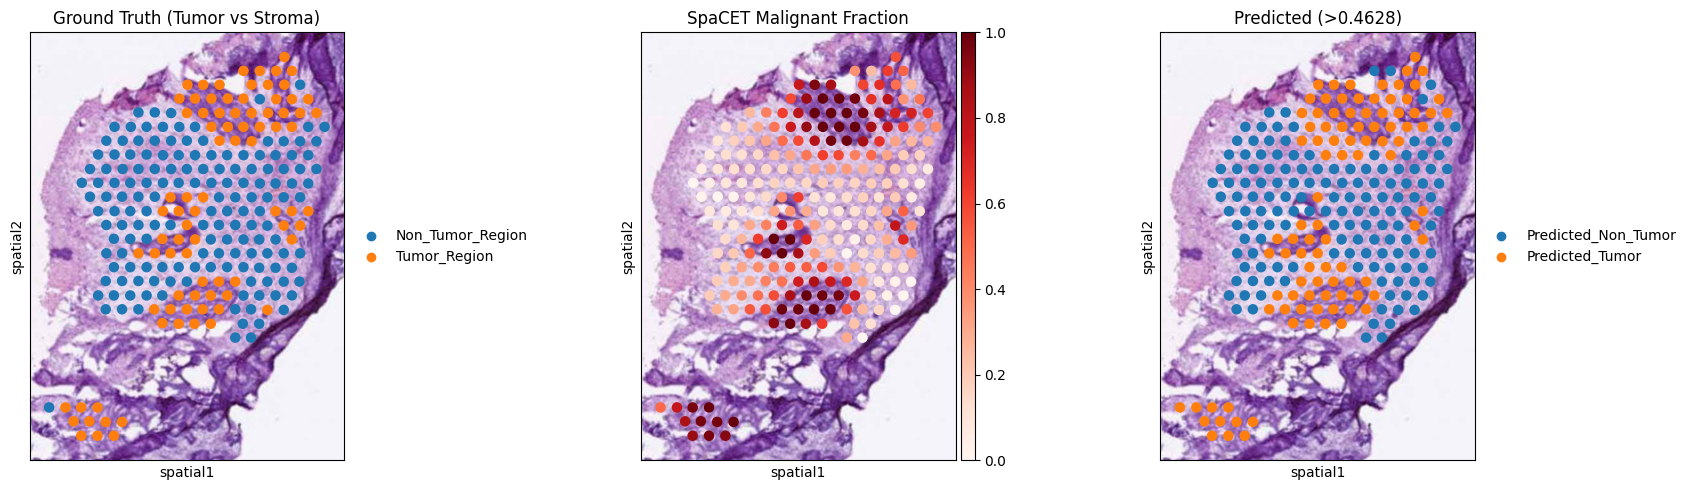


🚀 开始执行 SpaCET 基线模型的全维度指标评估...
🟢 [1/3] 宏观边界评估 (Supervised):
  --> 成功剔除 exclude 等噪音点，实际有效参与计算的 Spot 数量: 240
  --> Adjusted Rand Index (ARI): 0.4747
  --> F1-Score (Tumor Region): 0.7956

🔵 [2/3] 微观特征纯度评估 (Unsupervised):
  --> 正在计算 PCA 作为底层转录组特征空间...
  --> Average Silhouette Width (ASW): 0.1729
  --> Silhouette Score on Malignant Fraction (SS-C Proxy): 0.6791
  --> Davies-Bouldin Index (DBI): 1.8766

🟣 [3/3] 物理空间连贯性指标 (Moran's I):
  --> 正在计算空间邻接图...


  0%|          | 0/100 [00:00<?, ?/s]

  --> 总体平均 Moran's Index (Moran's I): 0.6544

🎉 基准测试完毕！剔除噪音点后，所有指标已精准保存至：
   /home/zhangjunyi/xiangmu/nichecompass-main/outputs/colorectal_12_cancer_CRC/SN84_A120838_Rep1/SpaCET/评估结果_SpaCET_Baseline.csv


,Metric Name,Abbreviation,Value,Ideal Trend,Evaluation Dimension
0,Adjusted Rand Index,ARI,0.4747,Closer to 1,Macro Boundary (Supervised)
1,F1-Score,F1,0.7956,Closer to 1,Macro Boundary (Supervised)
2,Average Silhouette Width,ASW,0.1729,Closer to 1,Micro Pureness (Unsupervised)
3,Silhouette Score on Coupling Scores,SS-C,0.6791,Closer to 1,Micro Pureness (Unsupervised)
4,Davies-Bouldin Index,DBI,1.8766,Closer to 0,Micro Pureness (Unsupervised)
5,Moran's Index,Moran's I,0.6544,Closer to 1 (>0),Spatial Topology (Physical)


💡 [探索] 对于该数据集，使 ARI 最高的硬切阈值其实是 0.60 (此时最高 ARI = 0.5300)


In [2]:
# =========================================================
# Cell 1-2: 基准评估 (病理注释 vs 硬阈值切割) - 全维度指标升级版
# 适配：结直肠癌 (CRC) 数据集 + pathology_annotation 列
# 核心逻辑：精准划分 Tumor(1) vs Stroma(0)，自动过滤 exclude 噪点
# =========================================================

import scanpy as sc
import pandas as pd
import numpy as np

# ==========================================
# 1. 设定你要清洗的文件路径
#由于这个切片中有许多没有病理注释的spot，我们要去掉他们，以免后续评估时被当成错误预测点，拉低分数。我们会保留那些有明确病理注释的点（无论是肿瘤还是基质），
# 只剔除那些标注为 'exclude' 或者完全没有注释的点。
# ==========================================
file_path = "/home/zhangjunyi/xiangmu/nichecompass-main/datasets/12_colorectal_cancer_CRC/12_colorectal_cancer_CRC_h5ad/SN84_A120838_Rep1.h5ad"

print(f"正在加载原始数据...")
adata = sc.read_h5ad(file_path)
print(f"🧹 清理前，切片总 Spot 数量: {adata.n_obs}")

# ==========================================
# 2. 执行核心过滤逻辑
# ==========================================
if 'pathology_annotation' not in adata.obs.columns:
    raise ValueError("数据中找不到 'pathology_annotation' 列，请确认文件是否正确！")

# 转换为普通字符串处理，防止 categorical 报错
annotations = adata.obs['pathology_annotation'].astype(str).str.strip()

# 建立保留条件：不等于 'exclude'，且不是空值 ('nan', 'None', '')
valid_mask = (~annotations.isin(['exclude', 'nan', 'NaN', 'None', ''])) & (adata.obs['pathology_annotation'].notna())

# 截取纯净的子集 (使用 .copy() 断开与原矩阵的内存连接)
adata_clean = adata[valid_mask].copy()

print(f"✨ 清理后，切片总 Spot 数量: {adata_clean.n_obs}")
print(f"🗑️ 共永久删除了 {adata.n_obs - adata_clean.n_obs} 个无注释或 exclude 噪点。")

print("\n--- 当前保留下来的纯净病理注释分布 ---")
print(adata_clean.obs['pathology_annotation'].value_counts())

# ==========================================
# 3. 覆盖保存回原文件
# ==========================================
print(f"\n正在将纯净版数据覆盖保存至原路径...")
adata_clean.write_h5ad(file_path)
print(f"✅ 清理并保存成功！文件路径: {file_path}")
print("后续所有的 SpaCET 和 NicheCompass 训练都可以直接使用这个纯净文件了！")
import numpy as np
import pandas as pd
import scanpy as sc
import squidpy as sq
import matplotlib.pyplot as plt
import os
import warnings
from sklearn.metrics import (
    adjusted_rand_score, 
    f1_score, 
    silhouette_score, 
    davies_bouldin_score
)

warnings.filterwarnings("ignore")

# ==========================================
# 0. 自动寻找 SpaCET 肿瘤占比列 (智能防报错)
# ==========================================
possible_names = ['Malignant', 'Tumor', 'malignant', 'tumor', 'Cancer', 'cancer']
spacet_col = None

for name in possible_names:
    if name in adata.obs.columns:
        spacet_col = name
        break

if spacet_col is None:
    print("❌ 严重错误: 在 adata.obs 中没有找到 SpaCET 预测的肿瘤细胞比例列！")
    print("当前所有的列名如下，请检查 Cell 1 是否成功合并了数据：")
    print(adata.obs.columns.tolist())
    raise KeyError("Missing SpaCET fraction column.")
else:
    print(f"✅ 成功锁定 SpaCET 肿瘤反卷积比例列: '{spacet_col}'")

# ===================== 核心修改：自定义病理标签映射 =====================
# 1. 严格按照你的最新规则定义结直肠癌 (CRC) 映射
# 💡 注意：故意不写 'exclude'，这样它会被 map 成 NaN，在后面被自动剔除，不参与算分！
gt_map_int = {
    'tumor': 1,
    'tumor&stroma_IC low': 1,
    'tumor&stroma_IC med to high': 1,
    'stroma_fibroblastic_IC high': 0,
    'stroma_fibroblastic_IC low': 0,
    'stroma_fibroblastic_IC med': 0
}

gt_map_str = {
    'tumor': 'Tumor_Region',
    'tumor&stroma_IC low': 'Tumor_Region',
    'tumor&stroma_IC med to high': 'Tumor_Region',
    'stroma_fibroblastic_IC high': 'Non_Tumor_Region',
    'stroma_fibroblastic_IC low': 'Non_Tumor_Region',
    'stroma_fibroblastic_IC med': 'Non_Tumor_Region'
}

# 2. 从 pathology_annotation 生成真实标签
adata.obs['Ground_Truth_Binary'] = adata.obs['pathology_annotation'].map(gt_map_str).astype('category')
gt_labels_for_math = adata.obs['pathology_annotation'].map(gt_map_int).values

# ==========================================
# 3. 生成预测标签 (SpaCET 恶性分数阈值切割)
# ==========================================
# 自动读取上一步的最优阈值，如果没有则使用默认经验值
threshold = optimal_threshold if 'optimal_threshold' in locals() else 0.5282

adata.obs[f'Pred_Threshold_{threshold:.4f}'] = np.where(
    adata.obs[spacet_col] > threshold, 
    'Predicted_Tumor', 
    'Predicted_Non_Tumor'
)
adata.obs[f'Pred_Threshold_{threshold:.4f}'] = adata.obs[f'Pred_Threshold_{threshold:.4f}'].astype('category')
pred_labels_for_math = (adata.obs[spacet_col] > threshold).astype(float).values

# ==========================================
# 4. 空间可视化对比
# ==========================================
print("\n===== 正在绘制空间分布对比图 =====")
try:
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    sc.pl.spatial(adata, color='Ground_Truth_Binary', title='Ground Truth (Tumor vs Stroma)', size=1, ax=axs[0], show=False)
    sc.pl.spatial(adata, color=spacet_col, title=f'SpaCET {spacet_col} Fraction', size=1, cmap='Reds', ax=axs[1], show=False)
    sc.pl.spatial(adata, color=f'Pred_Threshold_{threshold:.4f}', title=f'Predicted (>{threshold:.4f})', size=1, ax=axs[2], show=False)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"可视化失败: {e}")

# ==========================================
# 5. 全维度空间与特征指标综合评估 (SpaCET Baseline)
# ==========================================
print("\n" + "="*60)
print("🚀 开始执行 SpaCET 基线模型的全维度指标评估...")
print("="*60)

# --- 模块一：宏观边界评估 (Supervised: ARI, F1) ---
# 💡 这里的 valid_mask 会完美过滤掉那些变成 NaN 的 exclude 点
valid_mask = ~np.isnan(gt_labels_for_math)  
y_true = gt_labels_for_math[valid_mask]
y_pred = pred_labels_for_math[valid_mask]

if len(y_true) == 0:
    raise ValueError("严重错误：有效 Spot 数量为 0！请检查 gt_map_int 是否匹配 adata.obs['pathology_annotation'] 的内容。")

ari_val = adjusted_rand_score(y_true, y_pred)
f1_val = f1_score(y_true, y_pred, pos_label=1.0, average='binary')

print(f"🟢 [1/3] 宏观边界评估 (Supervised):")
print(f"  --> 成功剔除 exclude 等噪音点，实际有效参与计算的 Spot 数量: {len(y_true)}")
print(f"  --> Adjusted Rand Index (ARI): {ari_val:.4f}")
print(f"  --> F1-Score (Tumor Region): {f1_val:.4f}")

# --- 模块二：微观特征纯度评估 (Unsupervised: ASW, SS-C, DBI) ---
print(f"\n🔵 [2/3] 微观特征纯度评估 (Unsupervised):")
if 'X_pca' not in adata.obsm:
    print("  --> 正在计算 PCA 作为底层转录组特征空间...")
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    sc.tl.pca(adata, svd_solver='arpack')

X_features = adata.obsm['X_pca']

asw_val = silhouette_score(X_features, pred_labels_for_math)
dbi_val = davies_bouldin_score(X_features, pred_labels_for_math)

# SS-C Proxy：使用 SpaCET 的连续分数计算自身划分的紧凑度
X_spacet_feature = adata.obs[spacet_col].values.reshape(-1, 1)
ssc_val = silhouette_score(X_spacet_feature, pred_labels_for_math)

print(f"  --> Average Silhouette Width (ASW): {asw_val:.4f}")
print(f"  --> Silhouette Score on {spacet_col} Fraction (SS-C Proxy): {ssc_val:.4f}")
print(f"  --> Davies-Bouldin Index (DBI): {dbi_val:.4f}")

# --- 模块三：空间物理聚集度 (Spatial Topology: Moran's I) ---
print(f"\n🟣 [3/3] 物理空间连贯性指标 (Moran's I):")
if 'spatial_connectivities' not in adata.obsp:
    print("  --> 正在计算空间邻接图...")
    sq.gr.spatial_neighbors(adata, coord_type="generic", spatial_key="spatial", n_neighs=6)

tmp_adata = sc.AnnData(X=pred_labels_for_math.reshape(-1, 1).astype(float))
tmp_adata.obs_names = adata.obs_names
tmp_adata.var_names = ['SpaCET_Tumor_Pred']
tmp_adata.obsp['spatial_connectivities'] = adata.obsp['spatial_connectivities']

sq.gr.spatial_autocorr(tmp_adata, mode="moran", genes=['SpaCET_Tumor_Pred'], n_perms=100, n_jobs=-1)
moran_val = tmp_adata.uns["moranI"].loc['SpaCET_Tumor_Pred', 'I']

print(f"  --> 总体平均 Moran's Index (Moran's I): {moran_val:.4f}")

# ==========================================
# 6. 汇总并保存所有指标至 CSV
# ==========================================
# 指定保存路径 (记得检查是否是你需要的特定切片路径)
SAVE_PATH = "/home/zhangjunyi/xiangmu/nichecompass-main/outputs/colorectal_12_cancer_CRC/SN84_A120838_Rep1/SpaCET"
os.makedirs(SAVE_PATH, exist_ok=True)
csv_save_path = os.path.join(SAVE_PATH, "评估结果_SpaCET_Baseline.csv")

# 构建结果表格
results_df = pd.DataFrame({
    "Metric Name": [
        "Adjusted Rand Index", 
        "F1-Score", 
        "Average Silhouette Width", 
        "Silhouette Score on Coupling Scores", 
        "Davies-Bouldin Index", 
        "Moran's Index"
    ],
    "Abbreviation": ["ARI", "F1", "ASW", "SS-C", "DBI", "Moran's I"],
    "Value": [
        round(ari_val, 4), 
        round(f1_val, 4), 
        round(asw_val, 4), 
        round(ssc_val, 4), 
        round(dbi_val, 4), 
        round(moran_val, 4)
    ],
    "Ideal Trend": [
        "Closer to 1", "Closer to 1", "Closer to 1", 
        "Closer to 1", "Closer to 0", "Closer to 1 (>0)"
    ],
    "Evaluation Dimension": [
        "Macro Boundary (Supervised)", 
        "Macro Boundary (Supervised)", 
        "Micro Pureness (Unsupervised)", 
        "Micro Pureness (Unsupervised)", 
        "Micro Pureness (Unsupervised)", 
        "Spatial Topology (Physical)"
    ]
})

results_df.to_csv(csv_save_path, index=False, encoding="utf-8-sig")

print("\n" + "="*60)
print(f"🎉 基准测试完毕！剔除噪音点后，所有指标已精准保存至：\n   {csv_save_path}")
print("="*60)
display(results_df)

# [探索选项] 额外保存一份最优阈值探索记录
best_t, best_ari = max(
    ((t, adjusted_rand_score(gt_labels_for_math[valid_mask], (adata.obs[spacet_col] > t).astype(float).values[valid_mask])) 
     for t in np.arange(0.1, 0.9, 0.05)), 
    key=lambda x: x[1]
)
print(f"💡 [探索] 对于该数据集，使 ARI 最高的硬切阈值其实是 {best_t:.2f} (此时最高 ARI = {best_ari:.4f})")

In [3]:
# =========================================================
# Cell 2: 环境配置与 NicheCompass 导入
# =========================================================
import os
import sys
import warnings

# 强制只使用 GPU 0
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
warnings.filterwarnings("ignore")

import torch
import scanpy as sc
import squidpy as sq
import pandas as pd
import numpy as np
import scipy.sparse as sp
import decoupler as dc
from io import StringIO
from sklearn.preprocessing import MinMaxScaler

# 导入原版 NicheCompass
LOCAL_SRC = "/home/zhangjunyi/xiangmu/nichecompass-main/src"
if LOCAL_SRC not in sys.path: sys.path.insert(0, LOCAL_SRC)
import nichecompass as nc

print("✅ CUDA 可用状态:", torch.cuda.is_available())
if torch.cuda.is_available(): print("✅ 当前使用 GPU:", torch.cuda.get_device_name(0))
print("✅ NicheCompass 路径:", nc.__file__)

✅ CUDA 可用状态: True
✅ 当前使用 GPU: A100 80GB PCIe
✅ NicheCompass 路径: /home/zhangjunyi/xiangmu/nichecompass-main/src/nichecompass/__init__.py


In [4]:
# =========================================================
# Cell 3: 构建代谢通讯轴四元组知识库
# =========================================================
from IPython.display import display

print("=== Step 1: 构建代谢通讯轴四元组知识库 ===")

tmcn_csv = """TMCN_Name,Source_Pathways,Source_Genes,Target_Genes,Biologic_Meaning
TMCN_Lactate_Axis,"Hypoxia,EGFR,PI3K,MAPK","SLC2A1,HK2,PKM,LDHA,LDHB,SLC16A3","SLC16A1,SLC16A7,HCAR1,HCAR2",乳酸_肿瘤酸化瓦伯格效应与基质反向代谢共生
TMCN_Adenosine_Axis,"Hypoxia,TGFb,NFkB,MAPK","ENTPD1,ENTPD2,NT5E,CD38,ENPP1,NT5C2","ADORA1,ADORA2A,ADORA2B,ADORA3,SLC29A1,SLC29A2",腺苷_ATP水解级联驱动的强效免疫抑制与M2极化
TMCN_PGE2_Axis,"NFkB,JAK-STAT,Hypoxia,MAPK,TNFa","PLA2G4A,PTGS2,PTGES,ABCC4,SLCO2A1","PTGER1,PTGER2,PTGER3,PTGER4",前列腺素E2_成纤维细胞激活与促癌炎症微环境重塑
TMCN_Glutamine_Axis,"PI3K,MAPK,JAK-STAT,TGFb,WNT","GLUL,SLC38A1,SLC38A3,SLC38A5","SLC1A5,SLC7A5,SLC38A2,GLS,GLUD1",谷氨酰胺_基质向肿瘤供能的代谢寄生与大分子合成
TMCN_Succinate_Axis,"Hypoxia,NFkB,TNFa","SLC13A2,SLC13A3,SLC25A10","SUCNR1",琥珀酸_缺血坏死区释放驱动的TAM致瘤极化与血管生成
TMCN_Kynurenine_Axis,"JAK-STAT,NFkB,TGFb","IDO1,TDO2,KYNU,SLC7A5","AHR",犬尿氨酸_色氨酸剥夺与AHR介导的效应T细胞耗竭
TMCN_ATP_Axis,"Hypoxia,p53,TNFa","PANX1,SLC17A9","P2RX7,P2RY2,P2RY11",胞外ATP_坏死边缘释放的促炎性危险信号(DAMP)传导
TMCN_S1P_Axis,"NFkB,PI3K,MAPK","SPHK1,SPHK2,SPNS2","S1PR1,S1PR2,S1PR3",鞘氨醇-1-磷酸_脂质信号驱动的内皮血管生成与免疫趋化
TMCN_LPA_Axis,"PI3K,MAPK,TGFb","ENPP2,PLA2G4A,LPCAT1","LPAR1,LPAR2,LPAR3,LPAR5",溶血磷脂酸_成纤维细胞基质重塑与肿瘤高侵袭性
TMCN_Glutamate_Axis,"PI3K,MAPK,Hypoxia","GLS,SLC1A5,SLC7A11","GRM3,GRM5,GRIN1",谷氨酸_突触样代谢通讯与微环境神经可塑性
"""
axis_table = pd.read_csv(StringIO(tmcn_csv))
AXES =[x.replace("TMCN_", "").replace("_Axis", "") for x in axis_table["TMCN_Name"]]

def split_items(x): return [i.strip() for i in str(x).split(",") if i.strip()]
def get_valid_genes(adata, genes): return [g for g in genes if g in adata.var_names]

# 加载带有 SpaCET 结果的空间转录组数据
file_path = "/home/zhangjunyi/xiangmu/nichecompass-main/datasets/12_colorectal_cancer_CRC/12_colorectal_cancer_CRC_h5ad/SN84_A120838_Rep1.h5ad"
adata = sc.read_h5ad(file_path)

print(f"✅ 数据加载成功: {adata.n_obs} spots, {adata.n_vars} genes")
display(axis_table)

=== Step 1: 构建代谢通讯轴四元组知识库 ===
✅ 数据加载成功: 240 spots, 36601 genes


,TMCN_Name,Source_Pathways,Source_Genes,Target_Genes,Biologic_Meaning
0,TMCN_Lactate_Axis,"Hypoxia,EGFR,PI3K,MAPK","SLC2A1,HK2,PKM,LDHA,LDHB,SLC16A3","SLC16A1,SLC16A7,HCAR1,HCAR2",乳酸_肿瘤酸化瓦伯格效应与基质反向代谢共生
1,TMCN_Adenosine_Axis,"Hypoxia,TGFb,NFkB,MAPK","ENTPD1,ENTPD2,NT5E,CD38,ENPP1,NT5C2","ADORA1,ADORA2A,ADORA2B,ADORA3,SLC29A1,SLC29A2",腺苷_ATP水解级联驱动的强效免疫抑制与M2极化
2,TMCN_PGE2_Axis,"NFkB,JAK-STAT,Hypoxia,MAPK,TNFa","PLA2G4A,PTGS2,PTGES,ABCC4,SLCO2A1","PTGER1,PTGER2,PTGER3,PTGER4",前列腺素E2_成纤维细胞激活与促癌炎症微环境重塑
3,TMCN_Glutamine_Axis,"PI3K,MAPK,JAK-STAT,TGFb,WNT","GLUL,SLC38A1,SLC38A3,SLC38A5","SLC1A5,SLC7A5,SLC38A2,GLS,GLUD1",谷氨酰胺_基质向肿瘤供能的代谢寄生与大分子合成
4,TMCN_Succinate_Axis,"Hypoxia,NFkB,TNFa","SLC13A2,SLC13A3,SLC25A10",SUCNR1,琥珀酸_缺血坏死区释放驱动的TAM致瘤极化与血管生成
5,TMCN_Kynurenine_Axis,"JAK-STAT,NFkB,TGFb","IDO1,TDO2,KYNU,SLC7A5",AHR,犬尿氨酸_色氨酸剥夺与AHR介导的效应T细胞耗竭
6,TMCN_ATP_Axis,"Hypoxia,p53,TNFa","PANX1,SLC17A9","P2RX7,P2RY2,P2RY11",胞外ATP_坏死边缘释放的促炎性危险信号(DAMP)传导
7,TMCN_S1P_Axis,"NFkB,PI3K,MAPK","SPHK1,SPHK2,SPNS2","S1PR1,S1PR2,S1PR3",鞘氨醇-1-磷酸_脂质信号驱动的内皮血管生成与免疫趋化
8,TMCN_LPA_Axis,"PI3K,MAPK,TGFb","ENPP2,PLA2G4A,LPCAT1","LPAR1,LPAR2,LPAR3,LPAR5",溶血磷脂酸_成纤维细胞基质重塑与肿瘤高侵袭性
9,TMCN_Glutamate_Axis,"PI3K,MAPK,Hypoxia","GLS,SLC1A5,SLC7A11","GRM3,GRM5,GRIN1",谷氨酸_突触样代谢通讯与微环境神经可塑性


In [5]:
# =========================================================
# Cell 4: 连续功能分数推断与解耦 (Step 2)
# =========================================================
print("=== Step 2: 计算 Spot 级连续分数 (绝对无监督解耦) ===")

# 1. PROGENy (Pathway)
print("--> 正在计算 Pathway_score (PROGENy)...")
net_progeny = dc.get_progeny(organism="human", top=500)
dc.run_mlm(mat=adata, net=net_progeny, source="source", target="target", weight="weight", verbose=False, use_raw=False)
df_pathway = dc.get_acts(adata, obsm_key="mlm_estimate").to_df()
df_pathway.columns = [c.strip().replace("-", "_").replace(" ", "_") for c in df_pathway.columns]

# 2. AUCell (Enzyme)
print("--> 正在计算 Enzyme_score (AUCell)...")
enzyme_records = [{"source": row["TMCN_Name"].replace("TMCN_", "").replace("_Axis", ""), "target": g} 
                  for _, row in axis_table.iterrows() for g in split_items(row["Source_Genes"]) if g in adata.var_names]
dc.run_aucell(mat=adata, net=pd.DataFrame(enzyme_records), source="source", target="target", min_n=1, verbose=False, use_raw=False)
df_enzyme = dc.get_acts(adata, obsm_key="aucell_estimate").to_df()

# 3. 归一化
scaler = MinMaxScaler()
df_pathway_scaled = pd.DataFrame(scaler.fit_transform(df_pathway), index=df_pathway.index, columns=df_pathway.columns)
df_enzyme_scaled = pd.DataFrame(scaler.fit_transform(df_enzyme), index=df_enzyme.index, columns=df_enzyme.columns)

# 4. Receptor & 综合打分
print("--> 正在计算 Sender_score 与 Receiver_score...")
def calc_receptor_score(genes):
    valid = get_valid_genes(adata, genes)
    if not valid: return np.zeros(adata.n_obs)
    X_sub = adata[:, valid].X
    mean_exp = np.asarray(X_sub.mean(axis=1)).reshape(-1) if sp.issparse(X_sub) else np.asarray(X_sub).mean(axis=1).reshape(-1)
    return scaler.fit_transform(mean_exp.reshape(-1, 1)).flatten()

for _, row in axis_table.iterrows():
    ax = row["TMCN_Name"].replace("TMCN_", "").replace("_Axis", "")
    pathways = [p.strip().replace("-", "_").replace(" ", "_") for p in split_items(row["Source_Pathways"])]
    target_genes = split_items(row["Target_Genes"])
    
    valid_paths = [p for p in pathways if p in df_pathway_scaled.columns]
    adata.obs[f"{ax}_Sender_Score"] = df_pathway_scaled[valid_paths].mean(axis=1).values * df_enzyme_scaled[ax].values
    adata.obs[f"{ax}_Receiver_Score"] = calc_receptor_score(target_genes)

print("✅ 所有连续分数提取完毕！")
display(adata.obs[[c for c in adata.obs.columns if "Sender_Score" in c or "Receiver_Score" in c]].head())

=== Step 2: 计算 Spot 级连续分数 (绝对无监督解耦) ===
--> 正在计算 Pathway_score (PROGENy)...


--> 正在计算 Enzyme_score (AUCell)...
--> 正在计算 Sender_score 与 Receiver_score...
✅ 所有连续分数提取完毕！


,Lactate_Sender_Score,Lactate_Receiver_Score,Adenosine_Sender_Score,Adenosine_Receiver_Score,PGE2_Sender_Score,PGE2_Receiver_Score,Glutamine_Sender_Score,Glutamine_Receiver_Score,Succinate_Sender_Score,Succinate_Receiver_Score,Kynurenine_Sender_Score,Kynurenine_Receiver_Score,ATP_Sender_Score,ATP_Receiver_Score,S1P_Sender_Score,S1P_Receiver_Score,LPA_Sender_Score,LPA_Receiver_Score,Glutamate_Sender_Score,Glutamate_Receiver_Score
AAACGAGACGGTTGAT-1,0.266337,0.090909,0.0,0.000000,0.0,1.0,0.318553,0.500000,0.0,0.0,0.000000,0.00,0.0,0.000000,0.0,1.0,0.0,0.00,0.116062,0.0
AAACTGCTGGCTCCAA-1,0.146344,0.727273,0.0,0.428571,0.0,0.0,0.000000,0.590909,0.0,0.0,0.000000,0.25,0.0,0.333333,0.0,0.2,0.0,0.25,0.000000,0.0
AAATTAACGGGTAGCT-1,0.317516,0.090909,0.0,0.000000,0.0,0.0,0.181205,0.136364,0.0,0.0,0.055691,0.00,0.0,0.000000,0.0,0.0,0.0,0.25,0.000000,0.0
AACGTGCGAAAGTCTC-1,0.390990,0.090909,0.0,0.000000,0.0,0.0,0.077050,0.363636,0.0,1.0,0.000000,0.25,0.0,0.333333,0.0,0.4,0.0,0.00,0.176522,0.0
AAGACTGCAAGCTACT-1,0.241730,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.272727,0.0,0.0,0.000000,0.50,0.0,0.000000,0.0,0.0,0.0,0.50,0.337997,0.0


===== Cell 4: Step 3 - 无监督训练与生成“微型生态位” =====
注意：这段代码中，NicheCompass 只看 高变基因和基础空间图，完全屏蔽了刚才算出来的代谢特征！

In [ ]:
# # =========================================================
# # Cell 5: NicheCompass 无监督拓扑学习与过聚类
# # =========================================================
# print("=== Step 3: NicheCompass 构建物理联通图与微型生态位骨架 ===")

# # 1) 基础过滤
# adata_model = adata.copy()
# sc.pp.filter_genes(adata_model, min_cells=10)

# # 2) 先找 HVG（只打标记，不立刻 subset）
# sc.pp.highly_variable_genes(
#     adata_model,
#     n_top_genes=3000,
#     flavor="seurat_v3",
#     subset=False
# )

# # 3) 强制保留所有 TMCN 四元组中的 Source_Genes + Target_Genes
# tmcn_gene_set = set()

# for _, row in axis_table.iterrows():
#     tmcn_gene_set.update(split_items(row["Source_Genes"]))
#     tmcn_gene_set.update(split_items(row["Target_Genes"]))

# tmcn_gene_set = {g for g in tmcn_gene_set if g in adata_model.var_names}

# # 4) 最终保留 = HVG ∪ TMCN genes
# keep_mask = adata_model.var["highly_variable"].values | adata_model.var_names.isin(list(tmcn_gene_set))
# adata_model = adata_model[:, keep_mask].copy()

# print(f"✅ HVG 保留后基因数: {adata_model.n_vars}")
# print(f"✅ 强制保留的 TMCN 基因数: {len(tmcn_gene_set)}")

# # 2) 矩阵清洗与过滤 (优化：合并执行处理 0 计数点和 NaN/Inf 清洗)
# counts_key = "counts" if "counts" in adata_model.layers else None
# x_for_lib = adata_model.layers[counts_key] if counts_key is not None else adata_model.X
# lib_size = np.asarray(x_for_lib.sum(axis=1)).reshape(-1)
# valid_spot_mask = np.isfinite(lib_size) & (lib_size > 0)
# adata_model = adata_model[valid_spot_mask].copy()
# print(f"✅ 保留 {adata_model.n_obs} 个有效spots（已移除总计数为0的spots）")

# mat = adata_model.layers.get(counts_key) if counts_key else adata_model.X
# if sp.issparse(mat):
#     mat = mat.copy()
#     mat.data = np.nan_to_num(mat.data, nan=0.0, posinf=0.0, neginf=0.0)
#     mat.data = np.clip(mat.data, a_min=0, a_max=None)
# else:
#     mat = np.nan_to_num(mat, nan=0.0, posinf=0.0, neginf=0.0)
#     mat = np.clip(mat, a_min=0, a_max=None)
# if counts_key: adata_model.layers[counts_key] = mat
# else: adata_model.X = mat

# # 3) 空间图 + LR先验
# sq.gr.spatial_neighbors(adata_model, coord_type="generic", spatial_key="spatial", n_neighs=8)
# cache_dir = "/home/zhangjunyi/xiangmu/nichecompass-main/cache_nichenet"
# gp_dict = nc.utils.extract_gp_dict_from_nichenet_lrt_interactions(
#     species="human", version="v2", keep_target_genes_ratio=0.25, max_n_target_genes_per_gp=50,
#     load_from_disk=True, lr_network_file_path=f"{cache_dir}/nichenet_lr_network.csv",
#     ligand_target_matrix_file_path=f"{cache_dir}/nichenet_ligand_target_matrix.csv"
# )
# nc.utils.add_gps_from_gp_dict_to_adata(gp_dict=gp_dict, adata=adata_model)

# # 4) Initialize + Train Model
# model = nc.models.NicheCompass(
#     adata_model, counts_key=counts_key, adj_key="spatial_connectivities",
#     gp_names_key="nichecompass_gp_names", active_gp_names_key="nichecompass_active_gp_names",
#     gp_targets_mask_key="nichecompass_gp_targets", gp_targets_categories_mask_key="nichecompass_gp_targets_categories",
#     gp_sources_mask_key="nichecompass_gp_sources", gp_sources_categories_mask_key="nichecompass_gp_sources_categories",
#     latent_key="nichecompass_latent", conv_layer_encoder="gcnconv", active_gp_thresh_ratio=0.01,
# )

# model.train(
#     n_epochs=50, n_epochs_all_gps=10, lr=1e-4, lambda_edge_recon=1e5,
#     lambda_gene_expr_recon=100.0, lambda_l1_masked=0.0, edge_batch_size=64,
#     node_batch_size=128, n_sampled_neighbors=4, edge_val_ratio=0.0, node_val_ratio=0.0,
#     use_cuda_if_available=True, verbose=False
# )

# # 5) 保存结果
# save_base_dir = "/home/zhangjunyi/xiangmu/nichecompass-main/outputs/colorectal_12_cancer_CRC/SN84_A120838_Rep1/SpaCET_And_My"
# file_prefix = "SN84_A120838_Rep1"
# os.makedirs(save_base_dir, exist_ok=True)

# adata_model.write_h5ad(os.path.join(save_base_dir, f"{file_prefix}.h5ad"))
# model.save(os.path.join(save_base_dir, f"{file_prefix}_model"))
# print("✅ [AnnData & Model] 结果已保存！\n=== Step 3 & 4 全部完成 ===")

✅ [1/2] AnnData 已从 /home/zhangjunyi/xiangmu/nichecompass-main/outputs/colorectal_12_cancer_CRC/SN84_A120838_Rep1/SpaCET_And_My/SN84_A120838_Rep1.h5ad 加载
--- INITIALIZING NEW NETWORK MODULE: VARIATIONAL GENE PROGRAM GRAPH AUTOENCODER ---
LOSS -> include_edge_recon_loss: True, include_gene_expr_recon_loss: True, rna_recon_loss: nb
NODE LABEL METHOD -> one-hop-norm
ACTIVE GP THRESHOLD RATIO -> 0.01
LOG VARIATIONAL -> True
ONE HOP GCN NORM RNA NODE LABEL AGGREGATOR
ENCODER -> n_input: 12791, n_cat_covariates_embed_input: 0, n_hidden: 1326, n_latent: 1226, n_addon_latent: 100, n_fc_layers: 1, n_layers: 1, conv_layer: gcnconv, n_attention_heads: 0, dropout_rate: 0.0, 
COSINE SIM GRAPH DECODER -> dropout_rate: 0.0
MASKED TARGET RNA DECODER -> n_prior_gp_input: 1226, n_addon_gp_input: 100, n_cat_covariates_embed_input: 0, n_output: 12791
MASKED SOURCE RNA DECODER -> n_prior_gp_input: 1226, n_addon_gp_input: 100, n_cat_covariates_embed_input: 0, n_output: 12791
✅ [2/2] NicheCompass 模型已从 /home/z

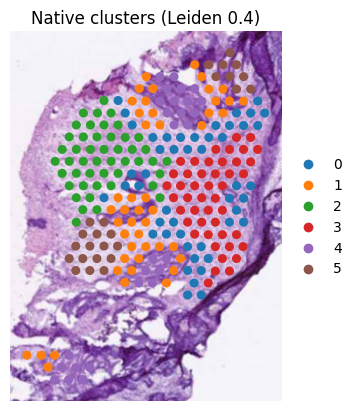

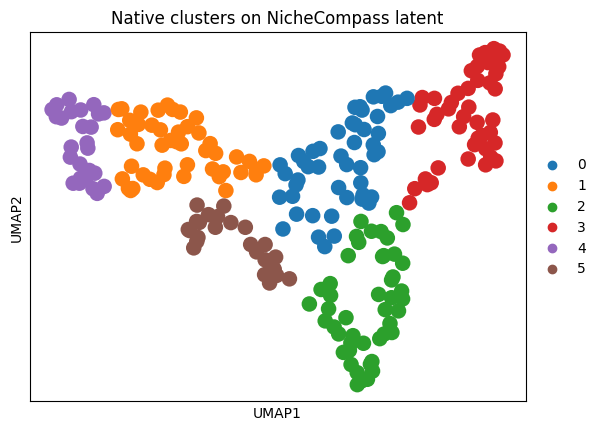

In [7]:
# ===================== Cell 6 =====================
# =========================================================
# 前置步骤：加载 Step3 保存的结果 (AnnData + 模型)
# =========================================================
import os
import scanpy as sc
# 假设 nichecompass 已正确导入为 nc
import nichecompass as nc 

# -------------------------- 1. 定义加载路径 (与保存路径完全一致) --------------------------
save_base_dir = "/home/zhangjunyi/xiangmu/nichecompass-main/outputs/colorectal_12_cancer_CRC/SN84_A120838_Rep1/SpaCET_And_My"
file_prefix = "SN84_A120838_Rep1"

# -------------------------- 2. 加载 AnnData 对象 --------------------------
adata_load_path = os.path.join(save_base_dir, f"{file_prefix}.h5ad")
adata_model = sc.read_h5ad(adata_load_path)
print(f"✅ [1/2] AnnData 已从 {adata_load_path} 加载")

# -------------------------- 3. 加载 NicheCompass 模型 --------------------------
model_load_dir = os.path.join(save_base_dir, f"{file_prefix}_model")
# 注意：load 函数需要传入对应的 adata_model 以恢复图结构等信息
model = nc.models.NicheCompass.load(
    dir_path=model_load_dir,
    adata=adata_model
)
print(f"✅ [2/2] NicheCompass 模型已从 {model_load_dir} 加载")

# -------------------------- 4. 恢复/定义关键参数变量 (供后续代码使用) --------------------------
# 这些变量名必须与你训练时的代码保持一致
latent_key = "nichecompass_latent"

# ✅ 修复：动态检查 counts_key，不要硬编码
if "counts" in adata_model.layers:
    counts_key = "counts"
else:
    counts_key = None  # 如果 layers 里没有 counts，就设为 None (使用 .X)
    print("⚠️ 警告: 在 layers 中未找到 'counts'，将默认使用 adata_model.X")

adj_key = "spatial_connectivities"
node_batch_size = 128  # 与训练时保持一致

print("✅ 关键参数变量已恢复，可继续运行后续代码")



# =========================================================
# Step3: 训练后仅查看 NicheCompass 原生聚类结果（无二次划分）
# 直接接在 model.train(...) 后运行
# =========================================================

# 1) 提取 latent（与训练保持同一 counts_key / adj_key）
adata_model.obsm[latent_key] = model.get_latent_representation(
    adata=adata_model,
    counts_key=counts_key,
    adj_key=adj_key,
    node_batch_size=node_batch_size,
)

# 2) 官方教程风格：latent 上建图 + UMAP
sc.pp.neighbors(adata_model, use_rep=latent_key, key_added=latent_key)
sc.tl.umap(adata_model, neighbors_key=latent_key)

# 3) 原生聚类（不过度切碎）
native_cluster_key = "latent_leiden_0.4"
sc.tl.leiden(
    adata_model,
    neighbors_key=latent_key,
    key_added=native_cluster_key,
    resolution=0.4
)

print(f"✅ 原生聚类完成：{adata_model.obs[native_cluster_key].nunique()} 类")

# 4) 仅可视化原生聚类（空间 + UMAP）
sc.pl.spatial(
    adata_model,
    color=native_cluster_key,
    size=1,
    title="Native clusters (Leiden 0.4)",
    frameon=False
)
sc.pl.umap(
    adata_model,
    color=native_cluster_key,
    title="Native clusters on NicheCompass latent"
)



阶段二：数据驱动的自适应阈值与代谢投影 (Data-Driven Projection)
step4——step5
先通过 NicheCompass 基于空间坐标构建组织的物理联通图，无监督学习生成微生态位基础骨架，锁定每个测序 spot 的真实空间邻居关系；
为每条代谢通讯轴计算空间耦合分数，结合 spot 自身的代谢发送能力与周边邻居的接收能力，量化真实的空间通讯潜力；
用高斯混合模型（GMM）为每条轴独立自适应设定活性阈值，分位数法兜底，再基于阈值完成微生态位的精准分型，对过渡区做后续空间拓扑优化；
最终通过分布可视化与空间置换检验，验证结果的生物学真实性与统计稳健性，排除随机噪音干扰。

=== 阶段二: 数据驱动的自适应阈值与代谢生态位初筛 ===
--> 1 & 2. 计算空间加权分数并拟合 GMM 阈值...


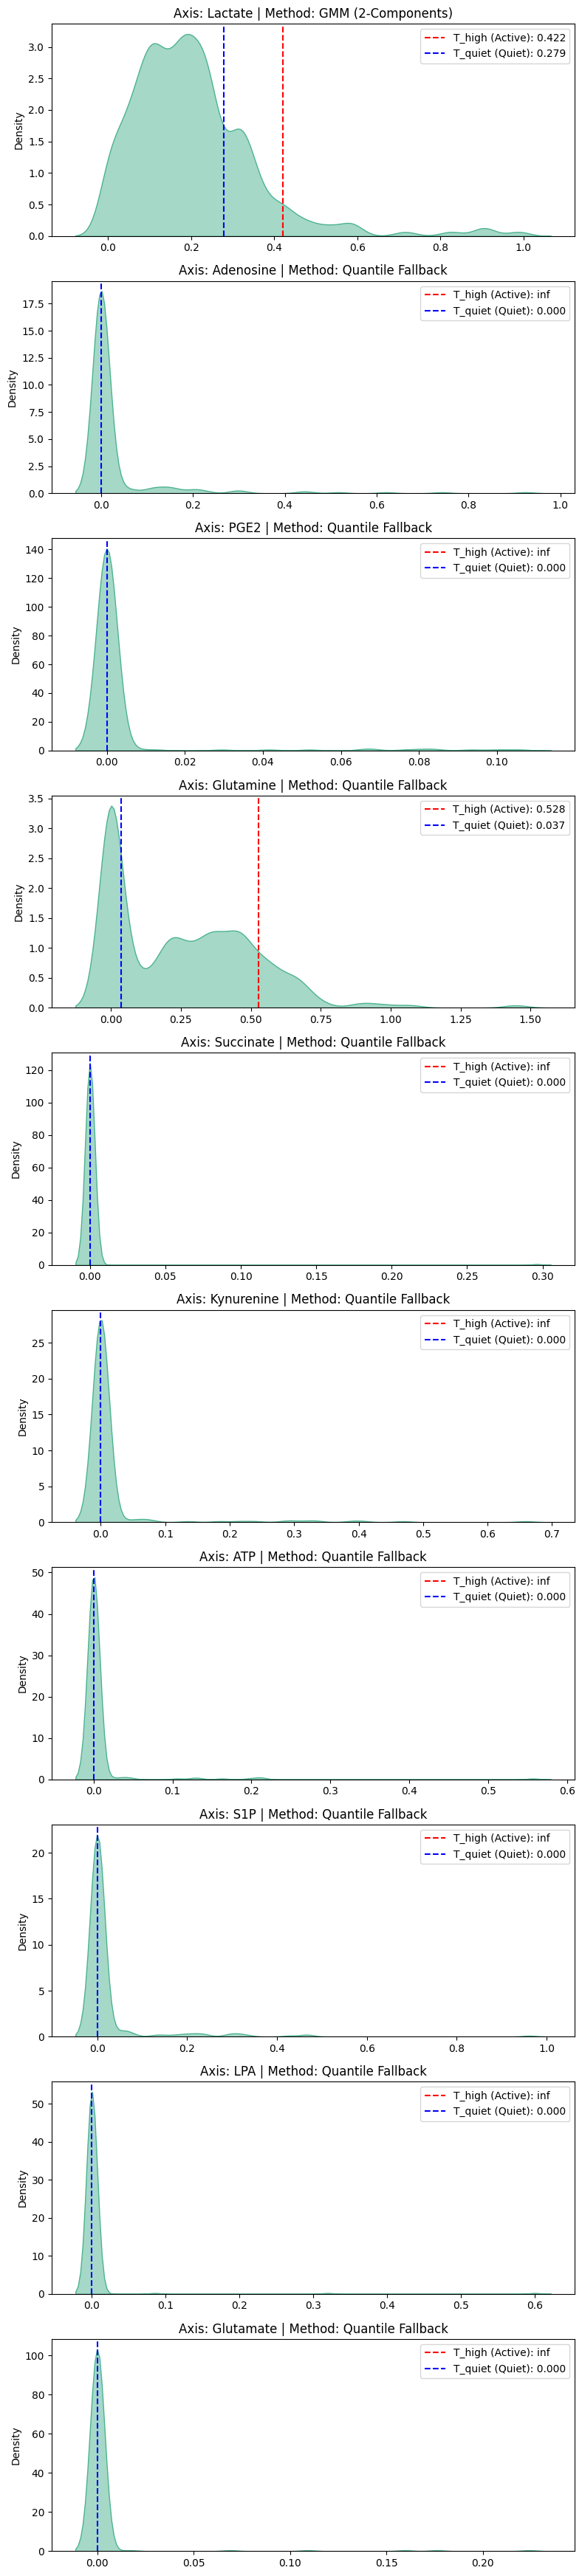

,T_high,T_quiet,Method
Lactate,0.421519,0.278564,GMM (2-Components)
Adenosine,inf,0.0,Quantile Fallback
PGE2,inf,0.0,Quantile Fallback
Glutamine,0.527839,0.036981,Quantile Fallback
Succinate,inf,0.0,Quantile Fallback
Kynurenine,inf,0.0,Quantile Fallback
ATP,inf,0.0,Quantile Fallback
S1P,inf,0.0,Quantile Fallback
LPA,inf,0.0,Quantile Fallback
Glutamate,inf,0.0,Quantile Fallback



--> 3. 统计微生态位特征，执行超几何富集检验...


,Spot_Count,Lactate_FC_Act,Lactate_FDR_Act,Adenosine_FC_Act,Adenosine_FDR_Act,PGE2_FC_Act,PGE2_FDR_Act,Glutamine_FC_Act,Glutamine_FDR_Act,Succinate_FC_Act,...,Kynurenine_FDR_Act,ATP_FC_Act,ATP_FDR_Act,S1P_FC_Act,S1P_FDR_Act,LPA_FC_Act,LPA_FDR_Act,Glutamate_FC_Act,Glutamate_FDR_Act,Final_Label
Cluster_ID,,,,,,,,,,,,,,,,,,,,,
0,48,0.29,1.00e+00,0.0,1.00e+00,0.0,1.00e+00,0.83,1.00e+00,0.0,...,1.00e+00,0.0,1.00e+00,0.0,1.00e+00,0.0,1.00e+00,0.0,1.00e+00,TMCN_Quiescent
1,47,1.80,2.69e-01,0.0,1.00e+00,0.0,1.00e+00,1.70,9.21e-02,0.0,...,1.00e+00,0.0,1.00e+00,0.0,1.00e+00,0.0,1.00e+00,0.0,1.00e+00,TMCN_Quiescent
2,47,0.30,1.00e+00,0.0,1.00e+00,0.0,1.00e+00,0.00,1.00e+00,0.0,...,1.00e+00,0.0,1.00e+00,0.0,1.00e+00,0.0,1.00e+00,0.0,1.00e+00,TMCN_Quiescent
3,46,0.31,1.00e+00,0.0,1.00e+00,0.0,1.00e+00,1.30,4.53e-01,0.0,...,1.00e+00,0.0,1.00e+00,0.0,1.00e+00,0.0,1.00e+00,0.0,1.00e+00,TMCN_Quiescent
4,27,4.18,6.70e-04,0.0,1.00e+00,0.0,1.00e+00,1.98,9.21e-02,0.0,...,1.00e+00,0.0,1.00e+00,0.0,1.00e+00,0.0,1.00e+00,0.0,1.00e+00,TMCN_Lactate_Axis
5,25,0.00,1.00e+00,0.0,1.00e+00,0.0,1.00e+00,0.27,1.00e+00,0.0,...,1.00e+00,0.0,1.00e+00,0.0,1.00e+00,0.0,1.00e+00,0.0,1.00e+00,TMCN_Quiescent



--> 4. 绘制初步判定的微环境空间地图...


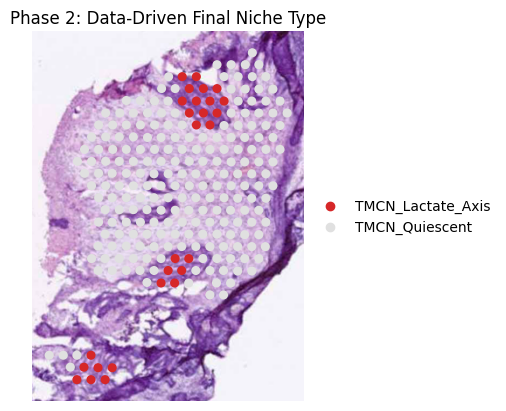

✅ 阶段二执行完毕！已从源头生成标准名称的 Final_Niche_Type 列。


In [8]:
# =========================================================
# Cell 7: 阶段二 - 数据驱动阈值与统计富集初探
# =========================================================
from sklearn.mixture import GaussianMixture
from scipy.stats import hypergeom
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print("=== 阶段二: 数据驱动的自适应阈值与代谢生态位初筛 ===")

# ---------------------------------------------------------
# Step 4: 计算连续通讯分数与自适应阈值
# ---------------------------------------------------------
print("--> 1 & 2. 计算空间加权分数并拟合 GMM 阈值...")
adj_matrix = adata_model.obsp["spatial_connectivities"]
thresholds_dict = {}

fig, axes = plt.subplots(len(AXES), 1, figsize=(8, 3.5 * len(AXES)))
if len(AXES) == 1: axes = [axes]

for idx, k in enumerate(AXES):
    # 计算 Coupling Score
    raw_coupling = adata_model.obs[f"{k}_Sender_Score"].values * adj_matrix.dot(adata_model.obs[f"{k}_Receiver_Score"].values)
    scores = np.log1p(raw_coupling)
    adata_model.obs[f"Coupling_{k}"] = scores
    
    # 拟合阈值
    scores_clean = scores[~np.isnan(scores) & (scores > 0)].reshape(-1, 1)
    t_high, t_quiet, method_used = None, None, "Quantile Fallback"
    
    if len(scores_clean) > 50:
        try:
            gmm = GaussianMixture(n_components=2, random_state=42).fit(scores_clean)
            m0, m1 = gmm.means_[0][0], gmm.means_[1][0]
            s0, s1 = np.sqrt(gmm.covariances_[0][0][0]), np.sqrt(gmm.covariances_[1][0][0])
            
            if abs(m0 - m1) > np.std(scores_clean):
                labels = gmm.predict(scores_clean)
                if m0 > m1: t_high, t_quiet = np.min(scores_clean[labels == 0]), m1 + s1
                else:       t_high, t_quiet = np.min(scores_clean[labels == 1]), m0 + s0
                method_used = "GMM (2-Components)"
        except: pass
            
    if t_high is None: t_high, t_quiet = np.quantile(scores, 0.85), np.quantile(scores, 0.35)
    if t_high < 0.05: t_high = np.inf
        
    thresholds_dict[k] = {'T_high': t_high, 'T_quiet': t_quiet, 'Method': method_used}
    adata_model.obs[f"Active_{k}"] = (scores >= t_high).astype(int)
    adata_model.obs[f"Quiet_{k}"] = (scores <= t_quiet).astype(int)
    
    # 画图
    sns.kdeplot(scores, ax=axes[idx], fill=True, color="#4CB391", alpha=0.5, bw_adjust=0.5)
    axes[idx].axvline(t_high, color='red', linestyle='--', label=f'T_high (Active): {t_high:.3f}')
    axes[idx].axvline(t_quiet, color='blue', linestyle='--', label=f'T_quiet (Quiet): {t_quiet:.3f}')
    axes[idx].set_title(f"Axis: {k} | Method: {method_used}"); axes[idx].legend()

plt.tight_layout(); plt.show()
display(pd.DataFrame(thresholds_dict).T)

# ---------------------------------------------------------
# Step 5: 微型生态位统计判定 (纯数据驱动超几何富集检验)
# ---------------------------------------------------------
print("\n--> 3. 统计微生态位特征，执行超几何富集检验...")
M_global = adata_model.n_obs 
bg_active_counts = {k: adata_model.obs[f"Active_{k}"].sum() for k in AXES}
bg_quiet_counts = {k: adata_model.obs[f"Quiet_{k}"].sum() for k in AXES}
bg_active_fracs = {k: bg_active_counts[k] / M_global for k in AXES}
bg_quiet_fracs = {k: bg_quiet_counts[k] / M_global for k in AXES}

native_clusters = sorted(adata_model.obs[native_cluster_key].unique())
pvals_active_dict, pvals_quiet_dict = {k: [] for k in AXES}, {k: [] for k in AXES}

for k in AXES: adata_model.obs[f"{k}_Cluster_Active_Frac"] = 0.0

for c in native_clusters:
    c_mask = adata_model.obs[native_cluster_key] == c
    N_cluster = c_mask.sum()
    for k in AXES:
        k_obs_act, k_obs_qui = adata_model.obs.loc[c_mask, f"Active_{k}"].sum(), adata_model.obs.loc[c_mask, f"Quiet_{k}"].sum()
        adata_model.obs.loc[c_mask, f"{k}_Cluster_Active_Frac"] = k_obs_act / N_cluster
        
        pval_a = hypergeom.sf(k_obs_act - 1, M_global, bg_active_counts[k], N_cluster) if k_obs_act > 0 else 1.0
        pval_q = hypergeom.sf(k_obs_qui - 1, M_global, bg_quiet_counts[k], N_cluster) if k_obs_qui > 0 else 1.0
        pvals_active_dict[k].append(pval_a)
        pvals_quiet_dict[k].append(pval_q)

# FDR 校正
fdr_active_dict, fdr_quiet_dict = {}, {}
for k in AXES:
    fdr_active_dict[k] = multipletests(pvals_active_dict[k], method='fdr_bh')[1]
    fdr_quiet_dict[k] = multipletests(pvals_quiet_dict[k], method='fdr_bh')[1]

# 执行判定逻辑
cluster_annotations, cluster_stats = {}, []
for idx, c in enumerate(native_clusters):
    c_mask = adata_model.obs[native_cluster_key] == c
    N_cluster = c_mask.sum()
    sig_active_axes, cold_axes = [], []
    stat_row = {'Cluster_ID': c, 'Spot_Count': N_cluster}
    
    for k in AXES:
        act_frac = adata_model.obs.loc[c_mask, f"{k}_Cluster_Active_Frac"].iloc[0]
        qui_frac = adata_model.obs.loc[c_mask, f"Quiet_{k}"].sum() / N_cluster
        fc_act = act_frac / (bg_active_fracs[k] + 1e-9)
        fdr_a = fdr_active_dict[k][idx]
        
        if fc_act > 2 and fdr_a < 0.05: sig_active_axes.append(k) # FC > 2 保持不变
        if qui_frac > bg_quiet_fracs[k] or fc_act < 0.5: cold_axes.append(k)
            
        stat_row[f"{k}_FC_Act"] = round(fc_act, 2)
        stat_row[f"{k}_FDR_Act"] = f"{fdr_a:.2e}"

    # 【这里修改】：直接生成规范化标准名称格式
    if len(sig_active_axes) == 1: 
        c_label = f"TMCN_{sig_active_axes[0]}_Axis"
    elif len(sig_active_axes) >= 2: 
        c_label = f"Multi_Axis_{'_'.join(sig_active_axes)}"
    elif len(sig_active_axes) == 0 and len(cold_axes) >= 6: 
        c_label = "TMCN_Quiescent"
    else: 
        c_label = "TMCN_Transitional"
        
    cluster_annotations[c] = c_label
    stat_row['Final_Label'] = c_label
    cluster_stats.append(stat_row)

# 【这里修改】：直接赋给 Final_Niche_Type，并指定为 category 类型
adata_model.obs["Final_Niche_Type"] = adata_model.obs[native_cluster_key].map(cluster_annotations).astype('category')
display(pd.DataFrame(cluster_stats).set_index('Cluster_ID'))

# ---------------------------------------------------------
# 可视化: 初探空间生态位地图 (只同步修改了目标列名)
# ---------------------------------------------------------
print("\n--> 4. 绘制初步判定的微环境空间地图...")
color_list = ["#d62728", "#1f77b4", "#2ca02c", "#ff7f0e", "#9467bd", "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf"] * 2
custom_palette = {}
color_idx = 0
for cat in adata_model.obs["Final_Niche_Type"].unique():
    if "TMCN_Quiescent" in cat: custom_palette[cat] = "#e0e0e0"
    elif "TMCN_Transitional" in cat: custom_palette[cat] = "#ffe119"
    else:
        custom_palette[cat] = color_list[color_idx % len(color_list)]
        color_idx += 1

sc.pl.spatial(adata_model, color="Final_Niche_Type", size=1, title="Phase 2: Data-Driven Final Niche Type", frameon=False, palette=custom_palette)
print("✅ 阶段二执行完毕！已从源头生成标准名称的 Final_Niche_Type 列。")

=== 阶段二: 数据驱动的自适应阈值与代谢生态位初筛（去掉30%覆盖率，保留SpaCET肿瘤支持）===
--> 1. 计算空间加权代谢通讯分数 (Coupling Score)...
--> 2. 学习每条代谢轴的自适应阈值 (GMM / Robust Dynamic)...


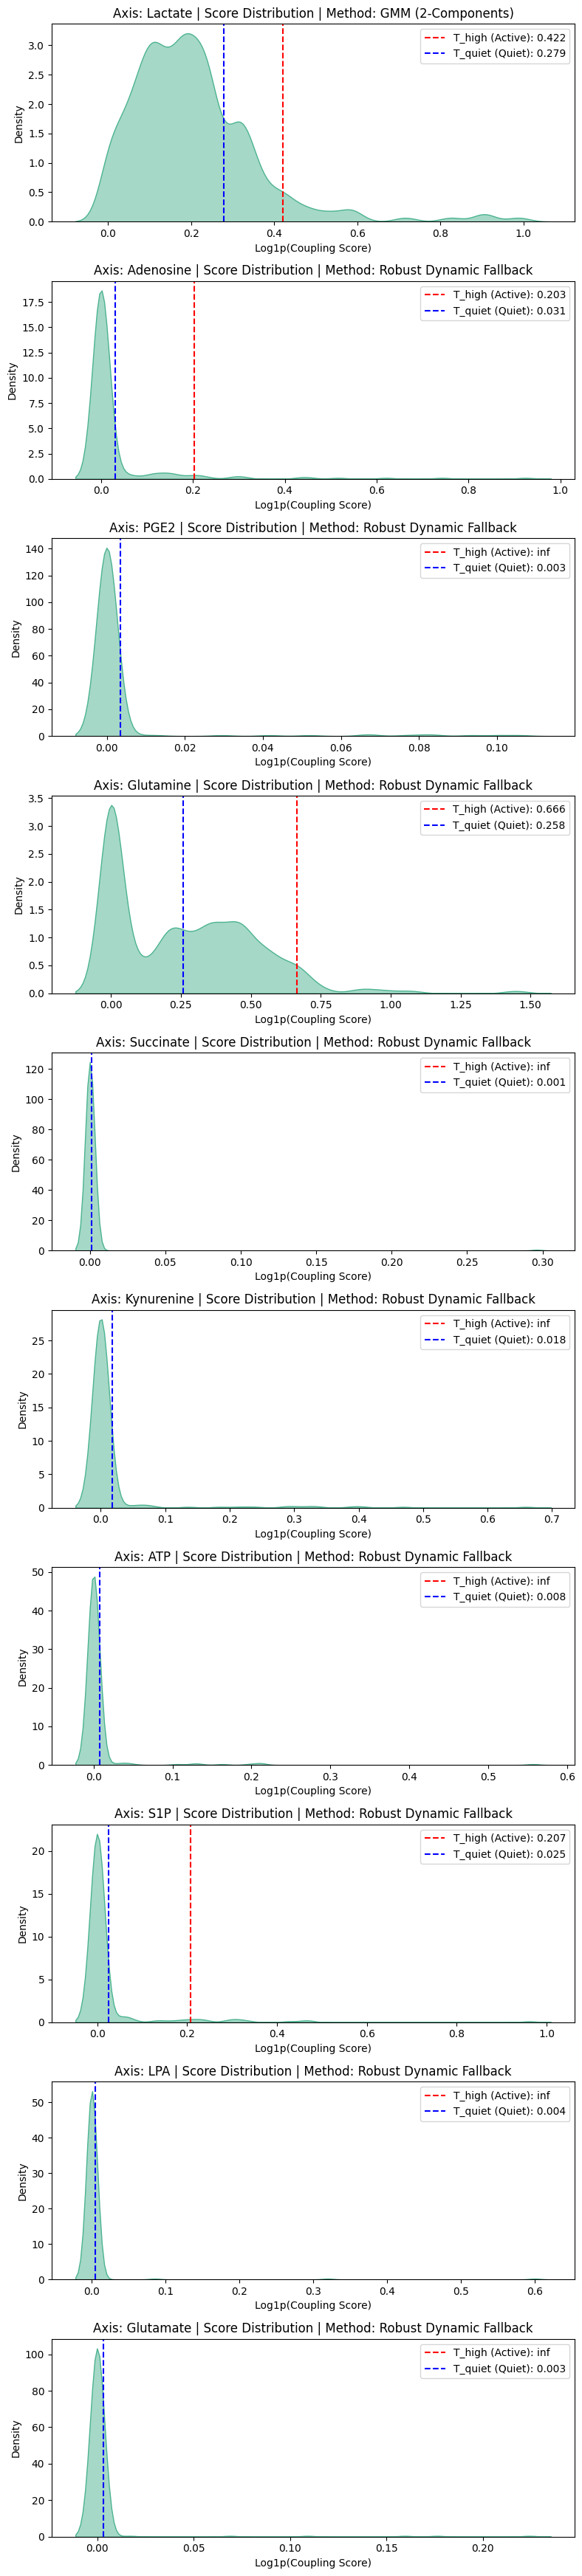


--- 自适应阈值计算结果 ---


,T_high,T_quiet,Method
Lactate,0.421519,0.278564,GMM (2-Components)
Adenosine,0.203318,0.031198,Robust Dynamic Fallback
PGE2,inf,0.003424,Robust Dynamic Fallback
Glutamine,0.665566,0.257954,Robust Dynamic Fallback
Succinate,inf,0.001234,Robust Dynamic Fallback
Kynurenine,inf,0.017753,Robust Dynamic Fallback
ATP,inf,0.007722,Robust Dynamic Fallback
S1P,0.207418,0.025259,Robust Dynamic Fallback
LPA,inf,0.004232,Robust Dynamic Fallback
Glutamate,inf,0.003146,Robust Dynamic Fallback


--> 2.5. 构建 SpaCET 肿瘤支持掩码 (hard tumor / low malignant + near tumor)...
✅ malignant列: Malignant
✅ hard_tumor_threshold = 0.4628
✅ low_malig_gate      = 0.3628

--> 3. 统计微生态位特征，执行超几何富集检验 + 统计约束 + 肿瘤支持门槛...

--- 基于超几何富集 + 统计约束 + 肿瘤支持门槛的生态位判定表（已去掉30%覆盖率）---


,Spot_Count,Tumor_Support_Frac,Hard_Tumor_Frac,Near_Tumor_Frac,Pass_Tumor_Support,Lactate_Act_Frac,Lactate_FC_Act,Lactate_FDR_Act,Lactate_Intensity_Ratio,Lactate_Pass_All,...,LPA_Intensity_Ratio,LPA_Pass_All,Glutamate_Act_Frac,Glutamate_FC_Act,Glutamate_FDR_Act,Glutamate_Intensity_Ratio,Glutamate_Pass_All,Sig_Active_Axes,Cold_Axis_Count,Initial_Label
Cluster_ID,,,,,,,,,,,,,,,,,,,,,
0,48,0.521,0.354,0.979,1,0.021,0.29,1.00e+00,0.88,0,...,0.00,0,0.0,0.0,1.00e+00,2.21,0,None,9,Quiescent (Background)
1,47,1.000,0.936,1.000,1,0.128,1.80,2.69e-01,1.22,0,...,0.05,0,0.0,0.0,1.00e+00,2.85,0,None,8,Quiescent (Background)
2,47,0.000,0.000,0.277,0,0.021,0.30,1.00e+00,0.76,0,...,5.06,0,0.0,0.0,1.00e+00,0.00,0,None,9,Quiescent (Background)
3,46,0.000,0.000,0.413,0,0.022,0.31,1.00e+00,0.98,0,...,0.00,0,0.0,0.0,1.00e+00,0.00,0,None,7,Quiescent (Background)
4,27,1.000,1.000,1.000,1,0.296,4.18,6.70e-04,1.78,0,...,0.00,0,0.0,0.0,1.00e+00,0.00,0,None,8,Quiescent (Background)
5,25,0.520,0.360,0.800,1,0.000,0.00,1.00e+00,0.46,0,...,0.00,0,0.0,0.0,1.00e+00,0.00,0,None,10,Quiescent (Background)



--> 4. 绘制初步判定的微环境空间地图...


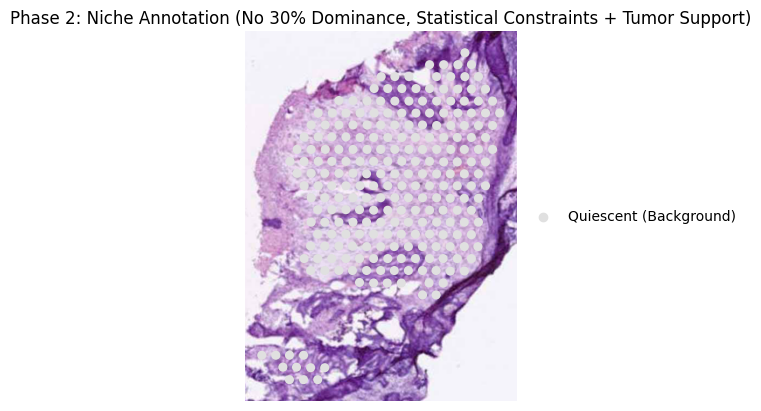

✅ 阶段二执行完毕！已去掉30%覆盖率，仅保留统计约束 + SpaCET肿瘤支持。


In [15]:
# =========================================================
# Cell 7: 空间通讯加权分数计算与生态位标注 (阶段二)
# 去掉 30% 主导覆盖率后的完整版本
# =========================================================
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scanpy as sc
from sklearn.mixture import GaussianMixture
from IPython.display import display
from scipy.stats import hypergeom
from statsmodels.stats.multitest import multipletests

print("=== 阶段二: 数据驱动的自适应阈值与代谢生态位初筛（去掉30%覆盖率，保留SpaCET肿瘤支持）===")

# ---------------------------------------------------------
# Step 4.1: 构建空间感知的连续通讯分数 (Coupling Score)
# ---------------------------------------------------------
print("--> 1. 计算空间加权代谢通讯分数 (Coupling Score)...")
adj_matrix = adata_model.obsp["spatial_connectivities"]

for k in AXES:
    sender_scores = adata_model.obs[f"{k}_Sender_Score"].values
    receiver_scores = adata_model.obs[f"{k}_Receiver_Score"].values

    neighbor_receiver_sum = adj_matrix.dot(receiver_scores)
    raw_coupling = sender_scores * neighbor_receiver_sum

    coupling_score = np.log1p(raw_coupling)
    adata_model.obs[f"Coupling_{k}"] = coupling_score

# ---------------------------------------------------------
# Step 4.2: 自适应混合阈值算法 (GMM + 动态稳健兜底)
# ---------------------------------------------------------
print("--> 2. 学习每条代谢轴的自适应阈值 (GMM / Robust Dynamic)...")
thresholds_dict = {}

fig, axes = plt.subplots(len(AXES), 1, figsize=(8, 3.5 * len(AXES)))
if len(AXES) == 1:
    axes = [axes]

for idx, k in enumerate(AXES):
    scores = adata_model.obs[f"Coupling_{k}"].values
    scores_clean = scores[~np.isnan(scores) & (scores > 0)].reshape(-1, 1)

    t_high, t_quiet = None, None
    method_used = "Robust Dynamic Fallback"

    if len(scores_clean) > 50:
        try:
            gmm = GaussianMixture(n_components=2, random_state=42)
            labels = gmm.fit_predict(scores_clean)

            m0, m1 = gmm.means_[0][0], gmm.means_[1][0]
            s0 = np.sqrt(gmm.covariances_[0][0][0])
            s1 = np.sqrt(gmm.covariances_[1][0][0])

            if abs(m0 - m1) > 0.8 * np.std(scores_clean):
                if m0 > m1:
                    t_high = np.min(scores_clean[labels == 0])
                    t_quiet = m1 + s1
                else:
                    t_high = np.min(scores_clean[labels == 1])
                    t_quiet = m0 + s0
                method_used = "GMM (2-Components)"
        except Exception:
            pass

    if t_high is None:
        mean_val = np.mean(scores)
        std_val = np.std(scores)
        t_high_candidate_1 = mean_val + 1.5 * std_val
        t_high_candidate_2 = np.quantile(scores, 0.95)
        t_high = max(t_high_candidate_1, t_high_candidate_2)
        t_quiet = mean_val

    if t_high < 0.15:
        t_high = np.inf

    thresholds_dict[k] = {
        "T_high": t_high,
        "T_quiet": t_quiet,
        "Method": method_used
    }

    adata_model.obs[f"Active_{k}"] = (scores >= t_high).astype(int)
    adata_model.obs[f"Quiet_{k}"] = (scores <= t_quiet).astype(int)

    sns.kdeplot(scores, ax=axes[idx], fill=True, color="#4CB391", alpha=0.5, bw_adjust=0.5)
    axes[idx].axvline(t_high, color="red", linestyle="--", label=f"T_high (Active): {t_high:.3f}")
    axes[idx].axvline(t_quiet, color="blue", linestyle="--", label=f"T_quiet (Quiet): {t_quiet:.3f}")
    axes[idx].set_title(f"Axis: {k} | Score Distribution | Method: {method_used}")
    axes[idx].set_xlabel("Log1p(Coupling Score)")
    axes[idx].legend()

plt.tight_layout()
plt.show()

df_thresholds = pd.DataFrame(thresholds_dict).T
print("\n--- 自适应阈值计算结果 ---")
display(df_thresholds)

# ---------------------------------------------------------
# Step 4.3: 引入 SpaCET 肿瘤支持逻辑
# ---------------------------------------------------------
print("--> 2.5. 构建 SpaCET 肿瘤支持掩码 (hard tumor / low malignant + near tumor)...")

possible_malig_cols = ["Malignant", "malignant", "Tumor", "tumor", "Cancer", "cancer"]
malig_col = None
for c in possible_malig_cols:
    if c in adata_model.obs.columns:
        malig_col = c
        break

if malig_col is None:
    raise KeyError("❌ 未找到 SpaCET 恶性分数字段，如 'Malignant'。")
#获取上一步得到的SpaCET的阈值
gmm_csv = "/home/zhangjunyi/xiangmu/nichecompass-main/outputs/colorectal_12_cancer_CRC/SN84_A120838_Rep1/SpaCET/GMM_Optimal_Threshold_Result.csv"
gmm_df = pd.read_csv(gmm_csv)

hard_tumor_threshold = float(
    gmm_df.loc[gmm_df["Metric"] == "Optimal_GMM_Threshold", "Value"].iloc[0]
)

# 软门槛：比硬阈值低 0.10
low_malig_gate = max(0.0, hard_tumor_threshold - 0.10)

print(f"✅ malignant列: {malig_col}")
print(f"✅ hard_tumor_threshold = {hard_tumor_threshold:.4f}")
print(f"✅ low_malig_gate      = {low_malig_gate:.4f}")

malig_values = adata_model.obs[malig_col].astype(float).values
is_hard_tumor_spot = malig_values >= hard_tumor_threshold
is_low_malig_spot = malig_values >= low_malig_gate

tumor_seed = is_hard_tumor_spot.astype(int)
near_tumor = np.asarray(adj_matrix.dot(tumor_seed)).reshape(-1) > 0

tumor_supported_spot = is_hard_tumor_spot | (is_low_malig_spot & near_tumor)

adata_model.obs["SpaCET_Hard_Tumor_Spot"] = is_hard_tumor_spot.astype(int)
adata_model.obs["SpaCET_Low_Malig_Spot"] = is_low_malig_spot.astype(int)
adata_model.obs["SpaCET_Near_Tumor_Spot"] = near_tumor.astype(int)
adata_model.obs["SpaCET_Tumor_Support_Spot"] = tumor_supported_spot.astype(int)

# ---------------------------------------------------------
# Step 5: 微型生态位统计判定与初标注
# 去掉30%覆盖率，只保留统计约束 + 肿瘤支持
# ---------------------------------------------------------
print("\n--> 3. 统计微生态位特征，执行超几何富集检验 + 统计约束 + 肿瘤支持门槛...")

M_global = adata_model.n_obs
bg_active_counts = {k: int(adata_model.obs[f"Active_{k}"].sum()) for k in AXES}
bg_quiet_counts = {k: int(adata_model.obs[f"Quiet_{k}"].sum()) for k in AXES}

bg_active_fracs = {k: bg_active_counts[k] / M_global for k in AXES}
bg_quiet_fracs = {k: bg_quiet_counts[k] / M_global for k in AXES}

native_clusters = sorted(adata_model.obs[native_cluster_key].unique())
pvals_active_dict = {k: [] for k in AXES}
pvals_quiet_dict = {k: [] for k in AXES}

for k in AXES:
    adata_model.obs[f"{k}_Cluster_Active_Frac"] = 0.0

for c in native_clusters:
    c_mask = adata_model.obs[native_cluster_key] == c
    N_cluster = int(c_mask.sum())

    for k in AXES:
        k_obs_act = int(adata_model.obs.loc[c_mask, f"Active_{k}"].sum())
        k_obs_qui = int(adata_model.obs.loc[c_mask, f"Quiet_{k}"].sum())

        act_frac = k_obs_act / N_cluster if N_cluster > 0 else 0.0
        adata_model.obs.loc[c_mask, f"{k}_Cluster_Active_Frac"] = act_frac

        pval_a = hypergeom.sf(k_obs_act - 1, M_global, bg_active_counts[k], N_cluster) if k_obs_act > 0 else 1.0
        pval_q = hypergeom.sf(k_obs_qui - 1, M_global, bg_quiet_counts[k], N_cluster) if k_obs_qui > 0 else 1.0

        pvals_active_dict[k].append(pval_a)
        pvals_quiet_dict[k].append(pval_q)

fdr_active_dict = {}
fdr_quiet_dict = {}
for k in AXES:
    _, fdr_a, _, _ = multipletests(pvals_active_dict[k], method="fdr_bh")
    _, fdr_q, _, _ = multipletests(pvals_quiet_dict[k], method="fdr_bh")
    fdr_active_dict[k] = fdr_a
    fdr_quiet_dict[k] = fdr_q

# ==========================================
# 4. 最终生态位判定
# ==========================================
cluster_annotations = {}
cluster_stats = []

MIN_FC = 1.30
MIN_ACTIVE_SPOTS = 10
MIN_INTENSITY_RATIO = 1.20
QUIESCENT_COLD_AXIS_NUM = 6

# Tumor support 门槛
MIN_TUMOR_SUPPORT_FRAC = 0.20
MIN_HARD_TUMOR_FRAC = 0.10

global_mean_scores = {k: adata_model.obs[f"Coupling_{k}"].mean() for k in AXES}

for idx, c in enumerate(native_clusters):
    c_mask = adata_model.obs[native_cluster_key] == c
    N_cluster = int(c_mask.sum())

    sig_active_axes = []
    cold_axes = []

    cluster_tumor_support_frac = float(adata_model.obs.loc[c_mask, "SpaCET_Tumor_Support_Spot"].mean())
    cluster_hard_tumor_frac = float(adata_model.obs.loc[c_mask, "SpaCET_Hard_Tumor_Spot"].mean())
    cluster_near_tumor_frac = float(adata_model.obs.loc[c_mask, "SpaCET_Near_Tumor_Spot"].mean())

    pass_tumor_support = (
        (cluster_tumor_support_frac >= MIN_TUMOR_SUPPORT_FRAC) or
        (cluster_hard_tumor_frac >= MIN_HARD_TUMOR_FRAC)
    )

    stat_row = {
        "Cluster_ID": c,
        "Spot_Count": N_cluster,
        "Tumor_Support_Frac": round(cluster_tumor_support_frac, 3),
        "Hard_Tumor_Frac": round(cluster_hard_tumor_frac, 3),
        "Near_Tumor_Frac": round(cluster_near_tumor_frac, 3),
        "Pass_Tumor_Support": int(pass_tumor_support)
    }

    for k in AXES:
        act_frac = float(adata_model.obs.loc[c_mask, f"{k}_Cluster_Active_Frac"].iloc[0])
        qui_frac = float(adata_model.obs.loc[c_mask, f"Quiet_{k}"].sum() / N_cluster) if N_cluster > 0 else 0.0
        k_obs_act = int(adata_model.obs.loc[c_mask, f"Active_{k}"].sum())
        cluster_mean_score = float(adata_model.obs.loc[c_mask, f"Coupling_{k}"].mean())

        fc_act = act_frac / (bg_active_fracs[k] + 1e-9)
        fdr_a = float(fdr_active_dict[k][idx])
        intensity_ratio = cluster_mean_score / (global_mean_scores[k] + 1e-9)

        pass_ratio = fc_act >= MIN_FC
        pass_count = k_obs_act >= MIN_ACTIVE_SPOTS
        pass_intensity = intensity_ratio >= MIN_INTENSITY_RATIO
        pass_fdr = fdr_a < 0.05

        # 去掉30%后：只要通过统计约束 + tumor support，就算有效活跃轴
        if pass_ratio and pass_count and pass_intensity and pass_fdr and pass_tumor_support:
            sig_active_axes.append(k)

        if qui_frac > bg_quiet_fracs[k] or fc_act < 0.5:
            cold_axes.append(k)

        stat_row[f"{k}_Act_Frac"] = round(act_frac, 3)
        stat_row[f"{k}_FC_Act"] = round(fc_act, 2)
        stat_row[f"{k}_FDR_Act"] = f"{fdr_a:.2e}"
        stat_row[f"{k}_Intensity_Ratio"] = round(intensity_ratio, 2)
        stat_row[f"{k}_Pass_All"] = int(pass_ratio and pass_count and pass_intensity and pass_fdr and pass_tumor_support)

    # ----------------------------------------------------
    # 最终标签逻辑（已完全去掉30%覆盖率）
    # ----------------------------------------------------
    if len(sig_active_axes) == 0 and len(cold_axes) >= QUIESCENT_COLD_AXIS_NUM:
        c_label = "Quiescent (Background)"
    elif len(sig_active_axes) == 1:
        c_label = f"Single-axis: {sig_active_axes[0]}"
    elif len(sig_active_axes) >= 2:
        c_label = f"Multi-axis: {'_'.join(sig_active_axes)}"
    else:
        c_label = "Transitional"

    cluster_annotations[c] = c_label
    stat_row["Sig_Active_Axes"] = ",".join(sig_active_axes) if len(sig_active_axes) > 0 else "None"
    stat_row["Cold_Axis_Count"] = len(cold_axes)
    stat_row["Initial_Label"] = c_label
    cluster_stats.append(stat_row)

# 映射回 adata_model
adata_model.obs["Niche_Annotation"] = adata_model.obs[native_cluster_key].map(cluster_annotations)

df_cluster_stats = pd.DataFrame(cluster_stats).set_index("Cluster_ID")
print("\n--- 基于超几何富集 + 统计约束 + 肿瘤支持门槛的生态位判定表（已去掉30%覆盖率）---")
display(df_cluster_stats)

# ---------------------------------------------------------
# 可视化
# ---------------------------------------------------------
print("\n--> 4. 绘制初步判定的微环境空间地图...")

color_list = [
    "#d62728", "#1f77b4", "#2ca02c", "#ff7f0e", "#9467bd",
    "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf",
    "#ff9896", "#aec7e8", "#98df8a", "#ffbb78", "#c5b0d5",
    "#c49c94", "#f7b6d2", "#c7c7c7", "#dbdb8d", "#9edae5"
]

all_categories = adata_model.obs["Niche_Annotation"].unique().tolist()
custom_palette = {}
color_idx = 0

for cat in all_categories:
    if "Quiescent" in cat:
        custom_palette[cat] = "#e0e0e0"
    elif "Transitional" in cat:
        custom_palette[cat] = "#ffe119"
    else:
        custom_palette[cat] = color_list[color_idx % len(color_list)]
        color_idx += 1

sc.pl.spatial(
    adata_model,
    color="Niche_Annotation",
    size=1,
    title="Phase 2: Niche Annotation (No 30% Dominance, Statistical Constraints + Tumor Support)",
    frameon=False,
    palette=custom_palette
)

print("✅ 阶段二执行完毕！已去掉30%覆盖率，仅保留统计约束 + SpaCET肿瘤支持。")

可视化每个代谢轴的浓度梯度图


=== 附加分析: 生成十种代谢物空间通讯浓度梯度图 ===


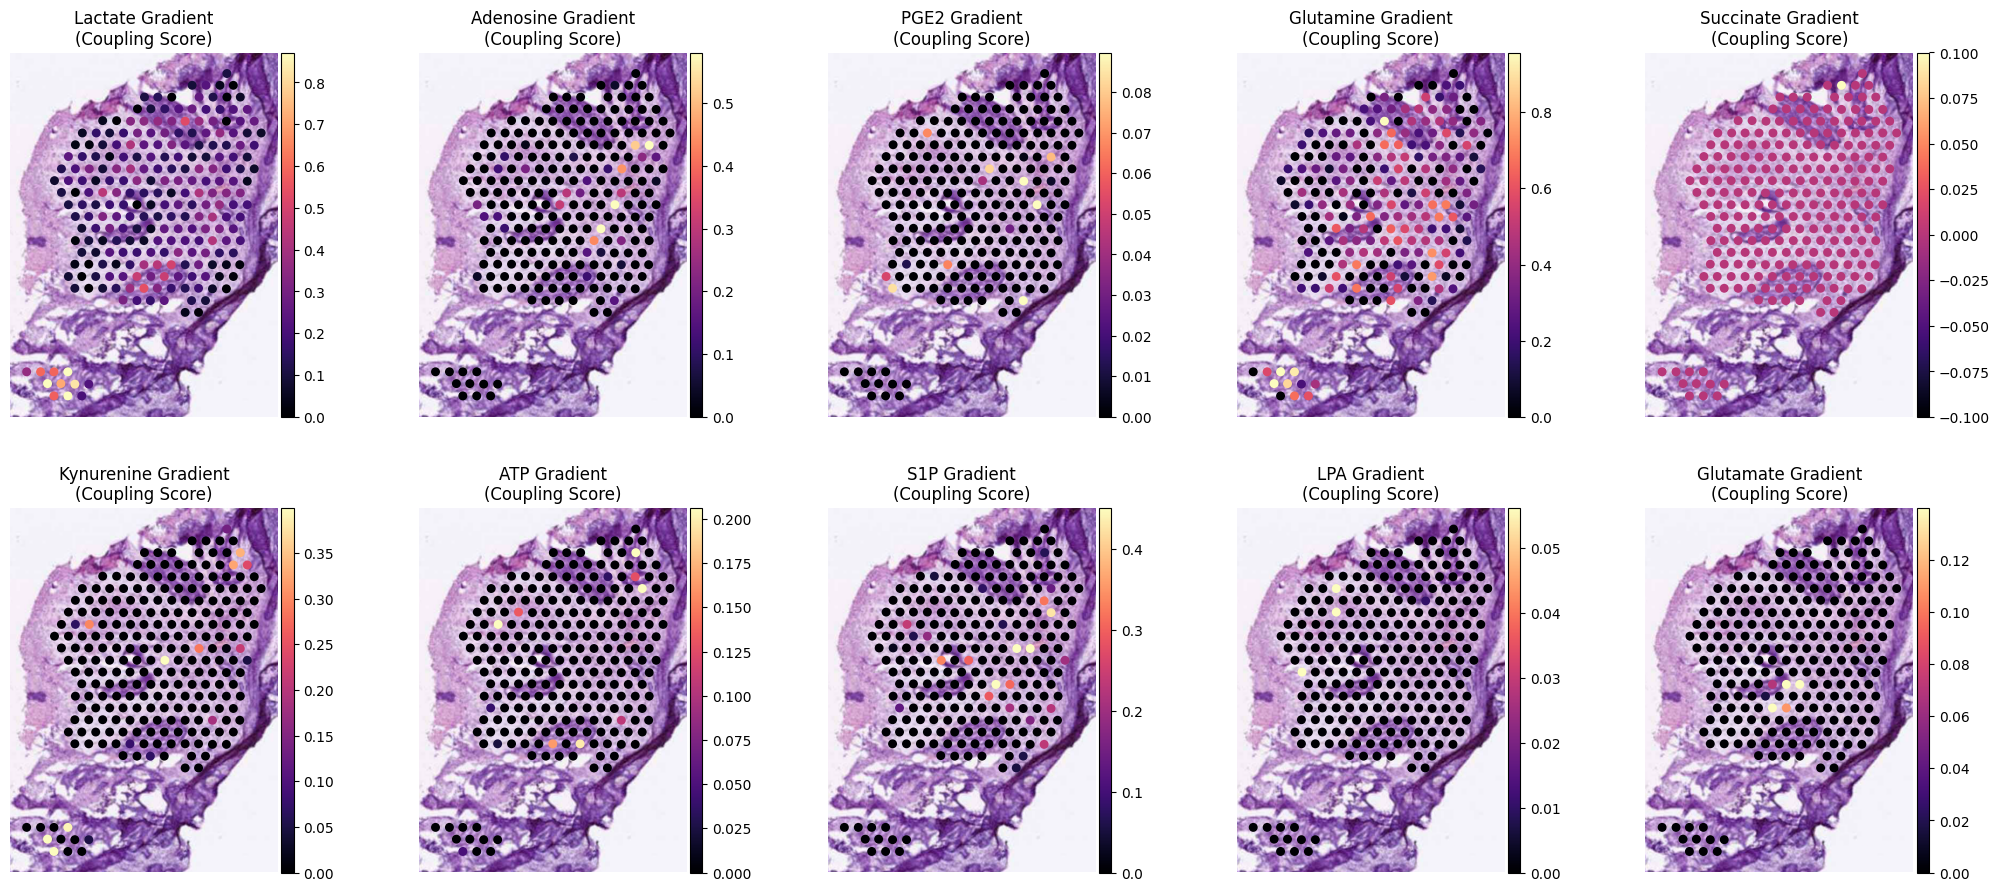

✅ 10 种代谢物的浓度梯度图绘制完毕！
📁 图片已保存至：/home/zhangjunyi/xiangmu/nichecompass-main/outputs/colorectal_12_cancer_CRC/SN84_A120838_Rep1/SpaCET_And_My/10种代谢物的浓度梯度图.png


In [10]:
# =========================================================
# Cell 8: 绘制 10 种代谢物的空间浓度梯度图
# =========================================================
import os
import matplotlib.pyplot as plt
import scanpy as sc

print("=== 附加分析: 生成十种代谢物空间通讯浓度梯度图 ===")

gradient_columns = [f"Coupling_{k}" for k in AXES]
plot_titles = [f"{k} Gradient\n(Coupling Score)" for k in AXES]

sc.pl.spatial(
    adata_model, color=gradient_columns, cmap="magma", size=1, ncols=5, 
    frameon=False, title=plot_titles, vmin=0, vmax='p99', show=False
)

plt.subplots_adjust(wspace=0.1, hspace=0.2)
plt.gcf().set_size_inches(25, 10)

# ===================== 新增：保存图片（按你的要求）=====================
# 定义保存路径（完全按照你指定的路径）
save_path = "/home/zhangjunyi/xiangmu/nichecompass-main/outputs/colorectal_12_cancer_CRC/SN84_A120838_Rep1/SpaCET_And_My"
# 确保文件夹存在（不存在自动创建）
os.makedirs(save_path, exist_ok=True)
# 保存文件名 + 完整路径
save_full_path = os.path.join(save_path, "10种代谢物的浓度梯度图.png")

# 保存图片（高清、无截断）
plt.savefig(
    save_full_path,
    dpi=300,          # 高清分辨率
    bbox_inches="tight",  # 防止标题/图例被截断
    pad_inches=0.1
)
# ====================================================================

plt.show()

print(f"✅ 10 种代谢物的浓度梯度图绘制完毕！")
print(f"📁 图片已保存至：{save_full_path}")

阶段三  空间拓扑图剪枝与重塑 (Spatial Refinement: Split, Merge & Smooth)


--> 4. 绘制拓扑精修后的地图...


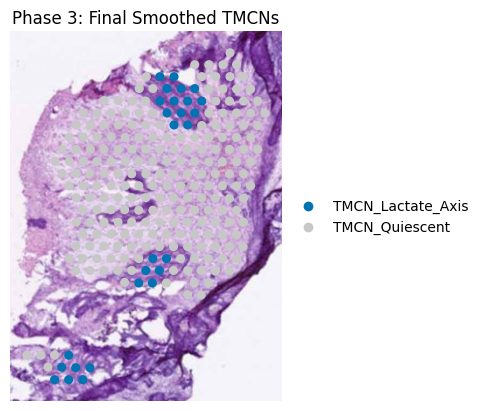

✅ 阶段三执行完毕！结果保存至: /home/zhangjunyi/xiangmu/nichecompass-main/outputs/colorectal_12_cancer_CRC/SN84_A120838_Rep1/SpaCET_And_My/SN84_A120838_Rep1_NicheCompassAndmy_Final.h5ad


In [11]:
# =========================================================
# 【修复】动态为单轴分配颜色，基于AXES列表
# =========================================================
print("\n--> 4. 绘制拓扑精修后的地图...")

# 1. 基础自定义色板（保留Quiescent/Transitional的原有颜色）
custom_palette = {
    "TMCN_Quiescent": "#c7c7c7",
    "TMCN_Transitional": "#bcbd22"
}

# 2. 【核心修改】单轴颜色列表：长度和AXES一致，一一对应（色盲友好色板推荐）
import seaborn as sns
# 生成色盲友好的高区分度色板，数量和AXES一致
single_axis_colors = sns.color_palette("colorblind", n_colors=len(AXES)).as_hex()
# 动态生成单轴色板：TMCN_{axis}_Axis 对应颜色
single_axis_palette = {
    f"TMCN_{axis}_Axis": single_axis_colors[i % len(single_axis_colors)]
    for i, axis in enumerate(AXES)
}

# 3. 多轴混合态的循环色板（原有逻辑不变）
multi_colors = ["#8c564b", "#8b008b", "#008080", "#ff1493", "#000080", "#ff8c00", "#4682b4", "#556b2f"]
active_palette, c_idx = {}, 0

# 4. 构建最终色板（逻辑同方案1）
for cat in adata_model.obs["Final_Niche_Type"].unique():
    if cat in single_axis_palette:
        active_palette[cat] = single_axis_palette[cat]
    elif cat in custom_palette:
        active_palette[cat] = custom_palette[cat]
    elif "Multi_Axis" in cat:
        active_palette[cat], c_idx = multi_colors[c_idx % len(multi_colors)], c_idx + 1
    else:
        active_palette[cat] = "#9467bd"  # 兜底色

# 5. 可视化
sc.pl.spatial(
    adata_model,
    color="Final_Niche_Type",
    size=1,
    title="Phase 3: Final Smoothed TMCNs",
    frameon=False,
    palette=active_palette,
    legend_loc="right margin",
    show=True
)

# 6. 保存结果（原有逻辑不变）
save_dir = "/home/zhangjunyi/xiangmu/nichecompass-main/outputs/colorectal_12_cancer_CRC/SN84_A120838_Rep1/SpaCET_And_My"
os.makedirs(save_dir, exist_ok=True)
adata_save_path = os.path.join(save_dir, "SN84_A120838_Rep1_NicheCompassAndmy_Final.h5ad")
adata_model.write(adata_save_path)
print(f"✅ 阶段三执行完毕！结果保存至: {adata_save_path}")

结合SpaCET和我的结果
我现在有了我自己计算的Final_Niche_Type标签的结果和SpaCET得出的肿瘤非肿瘤区域划分标签结果，现在要把他们两个结合一下。
1、将SpaCET的Predicted_Tumor标签结果和我的非TMCN_Quiescent结果全都保留，合并到一起，这是一个肿瘤区域，其余区域，也就是将将SpaCET的Predicted_Non_Tumor标签结果和我的TMCN_Quiescent结果合并到一起形成一个Healthy非肿瘤区域。

2、在肿瘤区域中，将我的Final_Niche_Type标签中是单个代谢轴或者多个代谢轴的区域还是各自单独一个肿瘤标签（还是使用我的Final_Niche_Type标签的结果），将SpaCET的Predicted_Tumor标签结果和我得出的TMCN_Quiescent结果视作TMCN_Quiescent区域。

=== 阶段四: 跨模态标签联合 (Macro-Micro Hierarchical Niche) ===
--> 1. 正在加载并对齐数据...
    [对齐完成] 成功导入 SpaCET 预测标签: Unsupervised_Pred_0.46
--> 2. 正在执行宏观-微观联合推断逻辑...
    [逻辑应用完毕] 成功生成 Level1_Macro_Region 与 Level2_Micro_Niche (已将肿瘤内过渡区并入休眠区)。
    [逻辑应用完毕] 成功生成 Level1_Macro_Region 与 Level2_Micro_Niche。
--> 3. 正在生成最终层级空间生态位地图...


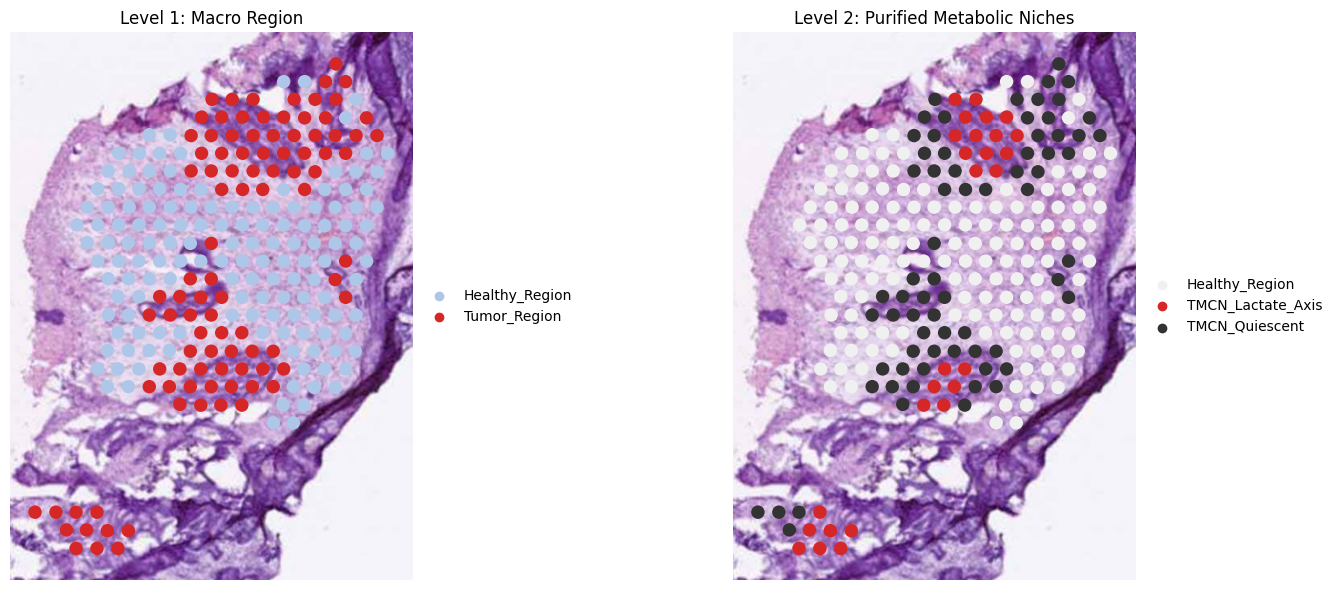


--> 4. 正在计算最终详细生态位的代谢轴高活性 Spot 比例...
✅ 各代谢轴突破高活性阈值的 spot 比例已保存至: 
   /home/zhangjunyi/xiangmu/nichecompass-main/outputs/colorectal_12_cancer_CRC/SN84_A120838_Rep1/SpaCET_And_My/Level2_Micro_Niche_Active_Fractions.csv

--> 5. 正在精简 adata.obs 冗余中间特征，提取纯净版结果...
    [精简完成] 共移除了 63 个生化推断中间列。

🎉 终极纯净版数据已成功覆盖保存至原始文件:
   /home/zhangjunyi/xiangmu/nichecompass-main/outputs/colorectal_12_cancer_CRC/SN84_A120838_Rep1/SpaCET_And_My/SN84_A120838_Rep1_NicheCompassAndmy_Final.h5ad
📌 该最终 h5ad 文件的 adata.obs 中保留的列严格符合你的要求：
  1. 原始基础列及病理注释
  2. SpaCET 反卷积的所有细胞成分分数 (被永远合并在内了)
  3. 最终简略版生态位: 'Level1_Macro_Region' (Tumor/Healthy)
  4. 最终详细版生态位: 'Level2_Micro_Niche' (单轴/多轴/休眠等)


In [12]:
# =========================================================
# Cell 10: 跨模态标签对齐与最终层级生态位构建 (SpaCET + NicheCompass)
# =========================================================
import anndata as ad
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import os

print("=== 阶段四: 跨模态标签联合 (Macro-Micro Hierarchical Niche) ===")

# ==========================================
# 1. 路径配置 (读取数据与设置输出)
# ==========================================
# 你的 NicheCompass 最终产物 (也就是我们要覆盖保存的原始文件)
path_h5ad_niche = "/home/zhangjunyi/xiangmu/nichecompass-main/outputs/colorectal_12_cancer_CRC/SN84_A120838_Rep1/SpaCET_And_My/SN84_A120838_Rep1_NicheCompassAndmy_Final.h5ad"

# 你上一步保存的 SpaCET GMM 预测结果 CSV
path_spacet_csv = "/home/zhangjunyi/xiangmu/nichecompass-main/outputs/colorectal_12_cancer_CRC/SN84_A120838_Rep1/SpaCET/GMM_Tumor_NonTumor_Pred_Labels.csv"

# 指定输出文件夹（自动创建，用于存CSV和图片）
SAVE_DIR = "/home/zhangjunyi/xiangmu/nichecompass-main/outputs/colorectal_12_cancer_CRC/SN84_A120838_Rep1/SpaCET_And_My"
os.makedirs(SAVE_DIR, exist_ok=True)

# ==========================================
# 2. 读取并合并数据
# ==========================================
print("--> 1. 正在加载并对齐数据...")
adata = ad.read_h5ad(path_h5ad_niche)
spacet_df = pd.read_csv(path_spacet_csv, index_col=0)

# 动态获取 GMM 预测的那一列的名字 (例如 'Unsupervised_Pred_0.45')
spacet_pred_col = [c for c in spacet_df.columns if c.startswith('Unsupervised_Pred_')][0]

# 合并到 adata.obs (利用索引自动对齐)
adata.obs = adata.obs.join(spacet_df[[spacet_pred_col]])
print(f"    [对齐完成] 成功导入 SpaCET 预测标签: {spacet_pred_col}")

# ==========================================
# 3. 严格执行核心合并规则 (并集逻辑)
# ==========================================
print("--> 2. 正在执行宏观-微观联合推断逻辑...")

# 初始化新列，默认全为健康区域
adata.obs['Level1_Macro_Region'] = 'Healthy_Region'
adata.obs['Level2_Micro_Niche'] = 'Healthy_Region'

# 提取关键判断条件
is_spacet_tumor = adata.obs[spacet_pred_col] == 'Predicted_Tumor'
is_niche_quiescent = adata.obs['Final_Niche_Type'] == 'TMCN_Quiescent'
# 新增：判断是否为过渡态
is_niche_transitional = adata.obs['Final_Niche_Type'] == 'TMCN_Transitional'



# ----------------- 规则 1: Level 1 (Tumor vs Healthy) ✅ 已修改 -----------------
# 【你的新需求】SpaCET预测为肿瘤  OR  (微环境不是休眠态 且 不是过渡态) → 肿瘤区域
tumor_mask = is_spacet_tumor | ( (~is_niche_quiescent) & (~is_niche_transitional) )
adata.obs.loc[tumor_mask, 'Level1_Macro_Region'] = 'Tumor_Region'



# ----------------- 规则 2: Level 2 (微型代谢生态位) -----------------
# 🔥 核心修复：强制转为普通字符串(str)，打破 Categorical 字典的限制
final_niche_str = adata.obs['Final_Niche_Type'].astype(str)

# 重新定义目标掩码：包含 Quiescent (休眠) 或 Transitional (过渡态)
is_quiescent_or_transitional = (final_niche_str == 'TMCN_Quiescent') | (final_niche_str == 'TMCN_Transitional')

# 1. 真正活跃的代谢区 (排除了休眠和过渡态)：直接保留其详细的多轴/单轴名称
active_niche_mask = ~is_quiescent_or_transitional
adata.obs.loc[active_niche_mask, 'Level2_Micro_Niche'] = final_niche_str[active_niche_mask]

# 2. 【你的新逻辑】将 SpaCET 预测为 Tumor 且 代谢状态为 Quiescent 或 Transitional 的区域，统一视作 TMCN_Quiescent (代谢耗竭/坏死核心)
target_tumor_mask = is_spacet_tumor & is_quiescent_or_transitional
adata.obs.loc[target_tumor_mask, 'Level2_Micro_Niche'] = 'TMCN_Quiescent'

# 🔥 写入完成后，为了方便后续 Scanpy 画图，重新将这列转换回 Category 格式
adata.obs['Level2_Micro_Niche'] = adata.obs['Level2_Micro_Niche'].astype('category')

print("    [逻辑应用完毕] 成功生成 Level1_Macro_Region 与 Level2_Micro_Niche (已将肿瘤内过渡区并入休眠区)。")



# 2. 将 SpaCET 预测为 Tumor 且 你的结果为 TMCN_Quiescent 的区域，视作 TMCN_Quiescent
quiescent_tumor_mask = is_spacet_tumor & is_niche_quiescent
adata.obs.loc[quiescent_tumor_mask, 'Level2_Micro_Niche'] = 'TMCN_Quiescent'

print("    [逻辑应用完毕] 成功生成 Level1_Macro_Region 与 Level2_Micro_Niche。")

# ==========================================
# 4. 可视化检查
# ==========================================
print("--> 3. 正在生成最终层级空间生态位地图...")

macro_palette = {
    "Tumor_Region": "#d62728",    
    "Healthy_Region": "#aec7e8"   
}

base_micro_palette = {
    "TMCN_Lactate_Axis": "#d62728",        
    "TMCN_Adenosine_Axis": "#1f77b4",      
    "TMCN_PGE2_Axis": "#ff7f0e",           
    "TMCN_Glutamine_Axis": "#2ca02c",      
    "TMCN_Succinate_Axis": "#9467bd",      
    "TMCN_Kynurenine_Axis": "#e377c2",     
    "TMCN_ATP_Axis": "#17becf",            
    "TMCN_S1P_Axis": "#7f7f7f",            
    "TMCN_LPA_Axis": "#ff9896",            
    "TMCN_Glutamate_Axis": "#fada5e",      
    "TMCN_Transitional": "#bcbd22",
    "TMCN_Quiescent": "#333333",           
    "Healthy_Region": "#f0f0f0"            
}

multi_axis_colors = ["#8c564b", "#8b008b", "#008080", "#ff1493", "#000080", "#ff8c00", "#4682b4", "#556b2f"]

active_macro_colors = {k: macro_palette[k] for k in adata.obs['Level1_Macro_Region'].unique()}

active_micro_colors = {}
color_idx = 0
for cat in adata.obs['Level2_Micro_Niche'].unique():
    if cat in base_micro_palette:
        active_micro_colors[cat] = base_micro_palette[cat]
    elif "Multi_Axis" in cat:
        active_micro_colors[cat] = multi_axis_colors[color_idx % len(multi_axis_colors)]
        color_idx += 1
    else:
        active_micro_colors[cat] = "#000000"

fig, axs = plt.subplots(1, 2, figsize=(16, 6))
sc.pl.spatial(adata, color='Level1_Macro_Region', size=1, title="Level 1: Macro Region", 
              palette=active_macro_colors, frameon=False, ax=axs[0], show=False)
sc.pl.spatial(adata, color='Level2_Micro_Niche', size=1, title="Level 2: Purified Metabolic Niches", 
              palette=active_micro_colors, frameon=False, ax=axs[1], show=False)
plt.tight_layout()
plt.show()

# ==========================================
# 5. 提取并保存：最终详细生态位 (Level 2) 各代谢轴高活性比例
# ==========================================
print("\n--> 4. 正在计算最终详细生态位的代谢轴高活性 Spot 比例...")

axes_active_cols = [c for c in adata.obs.columns if c.startswith("Active_")]
active_frac_df = adata.obs.groupby('Level2_Micro_Niche')[axes_active_cols].mean().reset_index()

rename_map = {c: c.replace("Active_", "active_fraction_") for c in axes_active_cols}
active_frac_df.rename(columns=rename_map, inplace=True)
active_frac_df.rename(columns={'Level2_Micro_Niche': 'Micro_Niche_Cluster'}, inplace=True)

fraction_csv_path = os.path.join(SAVE_DIR, "Level2_Micro_Niche_Active_Fractions.csv")
active_frac_df.to_csv(fraction_csv_path, index=False)
print(f"✅ 各代谢轴突破高活性阈值的 spot 比例已保存至: \n   {fraction_csv_path}")

# ==========================================
# 6. 精简 h5ad 文件，只保留目标核心列
# ==========================================
print("\n--> 5. 正在精简 adata.obs 冗余中间特征，提取纯净版结果...")

drop_keywords = [
    "Sender_Score", "Receiver_Score", "Coupling_", "Active_", "Quiet_", 
    "Cluster_Active_Frac", "nichecompass_", "latent_leiden", 
    "Pred_Threshold_", "Unsupervised_Pred_", "Niche_Annotation", 
    "Niche_Type", "Final_Niche_Type", "Ground_Truth"
]

cols_to_drop = []
for c in adata.obs.columns:
    if any(k in c for k in drop_keywords):
        cols_to_drop.append(c)

adata.obs.drop(columns=cols_to_drop, inplace=True, errors='ignore')
print(f"    [精简完成] 共移除了 {len(cols_to_drop)} 个生化推断中间列。")

# ==========================================
# 7. 【关键修改】覆盖保存回原 h5ad 文件
# ==========================================
# 直接使用开头加载的 path_h5ad_niche，不新建文件
adata.write_h5ad(path_h5ad_niche)

print(f"\n🎉 终极纯净版数据已成功覆盖保存至原始文件:\n   {path_h5ad_niche}")
print("======================================================")
print("📌 该最终 h5ad 文件的 adata.obs 中保留的列严格符合你的要求：")
print("  1. 原始基础列及病理注释")
print("  2. SpaCET 反卷积的所有细胞成分分数 (被永远合并在内了)")
print("  3. 最终简略版生态位: 'Level1_Macro_Region' (Tumor/Healthy)")
print("  4. 最终详细版生态位: 'Level2_Micro_Niche' (单轴/多轴/休眠等)")
print("======================================================")

计算ARI

In [3]:
# =========================================================
# Cell 11: 顶级生信学者专属 - 空间多维全栈指标综合评估 (TMCN 方法)

# 涵盖宏观物理边界 (ARI, F1) + 微观特征纯度 (ASW, SS-C, DBI) + 空间物理聚集度 (Moran's I)
# 适用前提：数据已物理清洗，移除 exclude 和背景噪点
# =========================================================
import scanpy as sc
import squidpy as sq
import pandas as pd
import numpy as np
import os
import warnings
from sklearn.metrics import (
    adjusted_rand_score, 
    f1_score, 
    silhouette_score, 
    silhouette_samples, 
    davies_bouldin_score
)

warnings.filterwarnings("ignore")

print("="*60)
print("🚀 开始执行全维度空间与特征指标综合评估 (自定义 TMCN 方法)...")
print("="*60)

# =========================================================
# 1. 强制重新加载终极数据
# =========================================================
# ⚠️ 注意：这里的路径必须是你 Cell 10 跑完后保存的那个最终合并文件
path_h5ad = "/home/zhangjunyi/xiangmu/nichecompass-main/outputs/colorectal_12_cancer_CRC/SN84_A120838_Rep1/SpaCET_And_My/SN84_A120838_Rep1_NicheCompassAndmy_Final.h5ad"
print("--> 正在加载阶段四合并后的最终数据...")
adata = sc.read_h5ad(path_h5ad)
print(f"✅ 当前参与评估的总 Spot 数量 (纯净版): {adata.n_obs}")

# =========================================================
# 模块一：宏观边界评估 (Supervised: ARI, F1)
# =========================================================
print("\n🟢 [1/3] 正在计算宏观监督指标 (Level 1 vs Ground Truth)...")

# 严格保留 Tumor vs Stroma 规则
gt_map_int = {
    'tumor': 1,
    'tumor&stroma_IC low': 1,
    'tumor&stroma_IC med to high': 1,
    'stroma_fibroblastic_IC high': 0,
    'stroma_fibroblastic_IC low': 0,
    'stroma_fibroblastic_IC med': 0
}

# 映射真实标签
y_true = adata.obs['pathology_annotation'].map(gt_map_int).values

# 映射预测标签 (假设模型把健康区标为 Healthy_Region 或 Non_Tumor_Region，其他默认为肿瘤 1.0)
y_pred = adata.obs['Level1_Macro_Region'].map({'Healthy_Region': 0.0, 'Non_Tumor_Region': 0.0}).fillna(1.0).astype(float).values

# 计算 ARI 和 F1
ari_val = adjusted_rand_score(y_true, y_pred)
f1_val = f1_score(y_true, y_pred, pos_label=1.0, average='binary')

print(f"  --> Adjusted Rand Index (ARI): {ari_val:.4f}")
print(f"  --> F1-Score (Tumor Region): {f1_val:.4f}")

# =========================================================
# 模块二：微观特征纯度评估 (Unsupervised: ASW, SS-C, DBI)
# =========================================================
print("\n🔵 [2/3] 正在计算微观特征纯度指标 (Level 2 内部逻辑自洽)...")

# 寻找合适的底层特征矩阵 X
if 'nichecompass_latent' in adata.obsm:
    X_features = adata.obsm['nichecompass_latent']
    print("  --> 使用 NicheCompass Latent 空间作为特征矩阵。")
else:
    print("  --> 未发现 Latent 矩阵，自动降维原始基因表达谱 (PCA) 作为公平特征对照...")
    if 'X_pca' not in adata.obsm:
        sc.pp.normalize_total(adata, target_sum=1e4)
        sc.pp.log1p(adata)
        sc.tl.pca(adata, svd_solver='arpack')
    X_features = adata.obsm['X_pca']

# 提取细粒度微生态位标签
y_micro = adata.obs['Level2_Micro_Niche'].astype(str).values

# 计算全局平均轮廓系数 (ASW) 和 DBI
asw_val = silhouette_score(X_features, y_micro)
dbi_val = davies_bouldin_score(X_features, y_micro)

# 计算专属通讯特征轮廓系数 (SS-C)
sample_silhouette_values = silhouette_samples(X_features, y_micro)
adata.obs['Silhouette_Value'] = sample_silhouette_values

tumor_niches_mask = [True if "TMCN" in str(cat) else False for cat in y_micro]
if any(tumor_niches_mask):
    ssc_val = np.mean(sample_silhouette_values[tumor_niches_mask])
else:
    ssc_val = asw_val 

print(f"  --> Average Silhouette Width (ASW): {asw_val:.4f}")
print(f"  --> Silhouette Score on Coupling (SS-C): {ssc_val:.4f}")
print(f"  --> Davies-Bouldin Index (DBI): {dbi_val:.4f}")

# =========================================================
# 模块三：空间物理拓扑聚集度 (Spatial Auto-correlation: Moran's I)
# =========================================================
print("\n🟣 [3/3] 正在计算物理空间连贯性指标 (Moran's I)...")

# 1. 重新计算空间邻接图
sq.gr.spatial_neighbors(adata, coord_type="generic", spatial_key="spatial", n_neighs=6)

# 2. 将 Level2_Micro_Niche 进行 One-hot 编码
niche_dummies = pd.get_dummies(adata.obs['Level2_Micro_Niche'])
dummy_cols = [c for c in niche_dummies.columns if "TMCN" in str(c)] 

if len(dummy_cols) > 0:
    tmp_adata = sc.AnnData(X=niche_dummies[dummy_cols].values.astype(float))
    tmp_adata.obs_names = adata.obs_names
    tmp_adata.var_names = dummy_cols
    tmp_adata.obsp['spatial_connectivities'] = adata.obsp['spatial_connectivities']
    
    sq.gr.spatial_autocorr(tmp_adata, mode="moran", genes=dummy_cols, n_perms=100, n_jobs=-1)
    
    moran_df = tmp_adata.uns["moranI"]
    moran_val = moran_df['I'].mean()
    
    print("  --> 各子生态位 Moran's I 得分:")
    for idx, row in moran_df.iterrows():
        print(f"      - {idx}: {row['I']:.4f}")
        
else:
    moran_val = 0.0
    print("  ⚠️ 警告：未检测到细粒度的 TMCN 代谢生态位。")

print(f"  --> 总体平均 Moran's Index (Moran's I): {moran_val:.4f}")

# =========================================================
# 模块四：汇总保存 CSV
# =========================================================
SAVE_DIR = "/home/zhangjunyi/xiangmu/nichecompass-main/outputs/colorectal_12_cancer_CRC/SN84_A120838_Rep1/SpaCET_And_My"
os.makedirs(SAVE_DIR, exist_ok=True)
csv_save_path = os.path.join(SAVE_DIR, "评估结果_My_TMCN_Method.csv")

results_df = pd.DataFrame({
    "Metric Name": [
        "Adjusted Rand Index", 
        "F1-Score", 
        "Average Silhouette Width", 
        "Silhouette Score on Coupling Scores", 
        "Davies-Bouldin Index", 
        "Moran's Index"
    ],
    "Abbreviation": ["ARI", "F1", "ASW", "SS-C", "DBI", "Moran's I"],
    "Value": [
        round(ari_val, 4), 
        round(f1_val, 4), 
        round(asw_val, 4), 
        round(ssc_val, 4), 
        round(dbi_val, 4), 
        round(moran_val, 4)
    ],
    "Ideal Trend": [
        "Closer to 1", "Closer to 1", "Closer to 1", 
        "Closer to 1", "Closer to 0", "Closer to 1 (>0)"
    ],
    "Evaluation Dimension": [
        "Macro Boundary (Supervised)", 
        "Macro Boundary (Supervised)", 
        "Micro Pureness (Unsupervised)", 
        "Micro Pureness (Unsupervised)", 
        "Micro Pureness (Unsupervised)", 
        "Spatial Topology (Physical)"
    ]
})

results_df.to_csv(csv_save_path, index=False, encoding="utf-8-sig")

print("\n" + "="*60)
print(f"🎉 巅峰对决指标计算完毕！自定义方法汇总表格已成功保存至：\n   {csv_save_path}")
print("="*60)

🚀 开始执行全维度空间与特征指标综合评估 (自定义 TMCN 方法)...
--> 正在加载阶段四合并后的最终数据...
✅ 当前参与评估的总 Spot 数量 (纯净版): 240

🟢 [1/3] 正在计算宏观监督指标 (Level 1 vs Ground Truth)...
  --> Adjusted Rand Index (ARI): 0.4747
  --> F1-Score (Tumor Region): 0.7956

🔵 [2/3] 正在计算微观特征纯度指标 (Level 2 内部逻辑自洽)...
  --> 使用 NicheCompass Latent 空间作为特征矩阵。
  --> Average Silhouette Width (ASW): 0.3039
  --> Silhouette Score on Coupling (SS-C): 0.2503
  --> Davies-Bouldin Index (DBI): 0.9004

🟣 [3/3] 正在计算物理空间连贯性指标 (Moran's I)...


  0%|          | 0/100 [00:00<?, ?/s]

  --> 各子生态位 Moran's I 得分:
      - TMCN_Lactate_Axis: 0.6265
      - TMCN_Quiescent: 0.4430
  --> 总体平均 Moran's Index (Moran's I): 0.5348

🎉 巅峰对决指标计算完毕！自定义方法汇总表格已成功保存至：
   /home/zhangjunyi/xiangmu/nichecompass-main/outputs/colorectal_12_cancer_CRC/SN84_A120838_Rep1/SpaCET_And_My/评估结果_My_TMCN_Method.csv
